# No-BESS vs BESS-Included Runs: Supervisor Deck Analysis

Produces the figures and tables for all 19 slides of the supervisor checklist deck, in
presentation order: run design, model configuration, inputs, model validation, results,
and limitations.

**Before running:**
- Set `RUN_A_PATH` / `RUN_B_PATH` in the config cell to your solved network files (`.nc`).
- Fill in every `# TODO` in the config cell with your actual Chapter 4/5 values, this
  notebook does not invent numbers for you, especially in Section 9 (Validation), where the
  observed comparison values must come from your primary sources, not be assumed.
- Confirm `BESS_CARRIER`, `EXISTING_BESS_NAMES`, `VRE_CARRIERS`, `THERMAL_CARRIERS` match your
  model's actual naming.
- **Check your BESS component representation** (`StorageUnit` vs `Store`+`Link`) in Section 10,
  before trusting anything about optimal BESS size/duration downstream.
- Section 2 auto-detects myopic multi-period vs single-period setup from
  `n.investment_periods`, if that comes back wrong, your model's investment period
  configuration differs from what this notebook assumes, fix the detection logic before
  trusting Section 14 (Energy Mix Over Time) or Section 18 (2050 map).


## 0. Setup & Configuration

In [132]:
import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

%matplotlib inline

# --- Thesis palette & figure style (keeps figures legible when exported to PDF) ---
PALETTE = {
    "blue_teal": "#0B4F6C",
    "amber": "#E8A33D",
    "slate": "#4A6572",
    "burgundy": "#7A3B46",
    "green": "#4B7A63",
}
RUN_COLORS = {"Run A (no BESS)": PALETTE["slate"], "Run B (BESS included)": PALETTE["blue_teal"]}

# carrier -> color, extend this to match every carrier in your model
CARRIER_COLORS = {
    "solar": PALETTE["amber"],
    "onwind": PALETTE["green"],
    "CCGT": PALETTE["slate"],
    "gas": PALETTE["slate"],
    "oil": PALETTE["burgundy"],
    "coal": "#2F2F2F",
    "lignite": "#8B5E3C",
    "biomass": "#7A9E7E",
    "battery": PALETTE["blue_teal"],
    "hydro": "#4FA5C4",
}
def color_for(carrier):
    return CARRIER_COLORS.get(carrier, "#999999")

def geo_bounds(n, pad_frac=0.08):
    '''Bounding box for buses with plausible lon/lat coordinates. Sector-coupling buses
    (e.g. an export bus in a projected CRS, or a co2-atmosphere bus with NaN coords) are
    excluded so a single outlier bus doesn't blow up the map extent and collapse the real
    network to a single point.'''
    xy = n.buses[["x", "y"]]
    valid = xy.notna().all(axis=1) & xy["x"].between(-180, 180) & xy["y"].between(-90, 90)
    xmin, xmax = xy.loc[valid, "x"].min(), xy.loc[valid, "x"].max()
    ymin, ymax = xy.loc[valid, "y"].min(), xy.loc[valid, "y"].max()
    xpad = (xmax - xmin) * pad_frac or 1.0
    ypad = (ymax - ymin) * pad_frac or 1.0
    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)

def electricity_links(n):
    '''Links that output real electricity to an AC bus, i.e. the actual power-plant capacity
    in a sector-coupled model (e.g. CCGT/oil/coal converting a fuel bus to AC). The raw
    fuel-supply Generator on the other side of these (carrier "gas"/"oil"/"coal"/...) is just
    a commodity-market feed, not installed electrical MW, and is deliberately NOT counted as
    generation capacity anywhere below. Excludes the BESS charger/discharger links, which are
    accounted for separately via get_bess_representation().'''
    if not len(n.links):
        return n.links
    bus1_carrier = n.buses["carrier"].reindex(n.links["bus1"]).values
    is_ac_output = bus1_carrier == "AC"
    is_bess = n.links["carrier"].isin(["battery charger", "battery discharger"])
    return n.links[is_ac_output & ~is_bess]

def capacity_by_carrier(n):
    '''Optimal/installed ELECTRICAL capacity by technology, combining:
    - Generators that connect directly to an AC bus (e.g. solar, onwind). Raw fuel-supply
      Generators (gas/oil/coal/... sitting on a fuel bus) are excluded, they are not
      installed electrical capacity.
    - StorageUnits (e.g. hydro), otherwise silently missing since they aren't Generators.
    - electricity_links() (e.g. CCGT, oil, coal power plants), where the real electrical
      capacity for these technologies actually lives in a sector-coupled model.'''
    g = n.generators[~n.generators.carrier.isin(NON_PHYSICAL_CARRIERS)]
    g = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    cap = g.p_nom_opt.where(g.p_nom_extendable, g.p_nom).groupby(g.carrier).sum()

    if len(n.storage_units):
        su = n.storage_units
        su_cap = su.p_nom_opt.where(su.p_nom_extendable, su.p_nom).groupby(su.carrier).sum()
        cap = cap.add(su_cap, fill_value=0)

    elink = electricity_links(n)
    if len(elink):
        elink_cap = elink.p_nom_opt.where(elink.p_nom_extendable, elink.p_nom).groupby(elink.carrier).sum()
        cap = cap.add(elink_cap, fill_value=0)

    return cap

def generation_by_carrier(n):
    '''Electrical dispatch by technology, same component coverage as capacity_by_carrier():
    AC-connected Generators, StorageUnits, and electricity_links() (using -p1, the actual
    electricity delivered to the AC bus, not p0 which is fuel/H2 withdrawn on the input side).'''
    g = n.generators
    g_ac = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    parts = [n.generators_t.p[g_ac.index].T.groupby(g_ac.carrier).sum().T]

    if len(n.storage_units):
        su = n.storage_units
        parts.append(n.storage_units_t.p.T.groupby(su.carrier).sum().T)

    elink = electricity_links(n)
    if len(elink):
        elec_out = -n.links_t.p1[elink.index]
        parts.append(elec_out.T.groupby(elink.carrier).sum().T)

    gen = pd.concat(parts, axis=1)
    return gen.T.groupby(level=0).sum().T

plt.rcParams.update({
    "figure.dpi": 100,        # on-screen
    "savefig.dpi": 300,       # export resolution for LaTeX/slide figures
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": True,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def savefig(fig, name):
    '''Save at 300 DPI with a tight bounding box, ready for slide/LaTeX use.'''
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")


In [133]:
# --- File paths ---
RUN_A_PATH = r"results/baseline_no_bess_2050_overnight/networks/elec_s_24_ec_lv1.0_1h.nc"   # restricted: BESS not investable, existing BESS excluded
RUN_B_PATH = r"results/baseline_bess_2050_overnight/networks/elec_s_24_ec_lv1.0_1h.nc"   # unrestricted: BESS power/energy/duration/siting optimized

# --- Model conventions ---
BESS_CARRIER = "battery"

# VRE_CARRIERS, THERMAL_CARRIERS, EXISTING_BESS_NAMES, and FUEL_PRICE are NOT hardcoded here,
# they're derived directly from the solved networks once n_a/n_b are loaded (see Section 1),
# since PyPSA-Earth already encodes this information: time-varying p_max_pu identifies VRE,
# non-extendable capacity identifies existing/committed assets, and generator marginal_cost
# on the raw fuel-supply generators already IS the fuel price. Hardcoding these risked drifting
# out of sync with the actual network (as happened here: "wind" vs "onwind", and a guessed gas
# CO2 factor that was 2x the model's own embedded value, see Section 16).

# Feasibility-slack generators PyPSA-Earth adds at every bus (electrical and otherwise) to
# guarantee the LP stays feasible. Very high marginal cost, essentially never dispatched in
# practice, capacity is a fixed safety-valve nameplate, not a real technology choice, exclude
# from capacity maps/tables so they don't visually dominate. Still checked properly, via actual
# dispatch rather than nameplate, in Section 17 Reliability.
NON_PHYSICAL_CARRIERS = ["load shedding"]

# --- Economic & policy parameters (Chapter 5 framework) --- TODO: replace with your actual values
SOC_DISCOUNT_RATE = 0.06
STP_DISCOUNT_RATE = 0.04
DISCOUNT_RATE = SOC_DISCOUNT_RATE
APPRAISAL_YEARS = 20
VOLL = 1000                          # currency / MWh. NOTE: this is YOUR Ch.5 economic value of
                                      # lost load for the appraisal, NOT the same thing as the
                                      # model's internal load-shedding penalty cost (a numerical
                                      # feasibility slack, ~1e6 currency/MWh, checked properly in
                                      # Section 17, and essentially never dispatched). Don't
                                      # conflate the two, they answer different questions.
DEMAND_GROWTH_PCT = 4.0              # % per year, from Ch. 4/5 demand projection
CARBON_PRICE = 0                     # currency / tCO2, 0 if not applying a shadow price
                                      # (confirmed: no CO2 budget/price global_constraint is
                                      # active in this solved network, so 0 is consistent)
SHADOW_EXCHANGE_RATE_PREMIUM = 0.0   # e.g. 0.10 for a 10% premium over the official rate

# --- Model validation targets --- TODO: fill in from your primary sources (Ch. 4), do not guess
OBSERVED_PEAK_DEMAND_MW = None
OBSERVED_GENERATION_MIX_PCT = {
    # "hfo": None, "diesel": None, "solar": None, "hydro_imports": None, ...
}


## 1. Run Design & Scenario Definition

Slide 1. Loads both networks, confirms they are identical except for BESS availability, and
reports which BESS assets are fixed in both runs (existing/committed) versus only buildable
in Run B.

In [134]:

n_a = pypsa.Network(RUN_A_PATH)
n_b = pypsa.Network(RUN_B_PATH)

print("Run A snapshots:", len(n_a.snapshots), "| Run B snapshots:", len(n_b.snapshots))
assert list(n_a.snapshots) == list(n_b.snapshots), "Snapshots differ between runs, check the model configs."

demand_a = n_a.loads_t.p_set.sum(axis=1)
demand_b = n_b.loads_t.p_set.sum(axis=1)
demand_diff = (demand_a - demand_b).abs().max()
print(f"Max hourly demand difference between runs: {demand_diff:.4f} MW")
if demand_diff > 1e-6:
    print("WARNING: demand differs between Run A and Run B, the comparison is no longer ceteris paribus.")

# Modelled year, parsed from the file paths, so every plot title below can say which year
# it's showing rather than leaving that implicit. Both runs must be the same year, otherwise
# the whole ceteris-paribus comparison is meaningless.
import re
def _extract_year(path):
    m = re.search(r"_(20[2-6]\d)_", str(path))
    if not m:
        raise ValueError(f"Could not detect a 4-digit year in path: {path}")
    return int(m.group(1))

year_a, year_b = _extract_year(RUN_A_PATH), _extract_year(RUN_B_PATH)
assert year_a == year_b, f"Run A ({year_a}) and Run B ({year_b}) are for different years, not comparable."
RUN_YEAR = year_a
print(f"Modelled year (both runs): {RUN_YEAR}")

print("\n--- Run design summary ---")
print("Run A: BESS excluded as an investable technology.")
print("Run B: BESS power, energy, duration & siting optimized.")
print("(Existing/committed BESS presence is checked in the next cell, once EXISTING_BESS_NAMES is derived.)")


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Run A snapshots: 8760 | Run B snapshots: 8760
Max hourly demand difference between runs: 0.0000 MW
Modelled year (both runs): 2050

--- Run design summary ---
Run A: BESS excluded as an investable technology.
Run B: BESS power, energy, duration & siting optimized.
(Existing/committed BESS presence is checked in the next cell, once EXISTING_BESS_NAMES is derived.)


In [135]:

# --- Derive model conventions directly from the solved networks ---
# Done here rather than in the Section 0 config cell, since it needs n_a/n_b to exist.

def _generator_carriers_with_profile(n):
    profiled = n.generators_t.p_max_pu.columns
    g = n.generators.loc[n.generators.index.isin(profiled)]
    g = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    return set(g.carrier.unique())

profiled_carriers = _generator_carriers_with_profile(n_a) | _generator_carriers_with_profile(n_b)
VRE_CARRIERS = sorted(profiled_carriers - set(NON_PHYSICAL_CARRIERS))
print(f"VRE_CARRIERS (auto-detected, time-varying p_max_pu on an AC bus): {VRE_CARRIERS}")

# THERMAL_CARRIERS = actual generation TECHNOLOGIES, not raw fuel commodities. Derived from
# electricity_links() (Links converting a fuel/H2 bus into AC power, e.g. CCGT/oil/coal power
# plants). In this sector-coupled model a Generator named "gas"/"oil"/"coal" is only the raw
# fuel-supply feed (near-zero/meaningless as installed capacity), the real electrical MW lives
# on the conversion Link, see capacity_by_carrier()/generation_by_carrier() in Section 0.
THERMAL_CARRIERS = sorted(set(electricity_links(n_a).carrier.unique()) | set(electricity_links(n_b).carrier.unique()))
print(f"THERMAL_CARRIERS (auto-detected, AC-output conversion Links): {THERMAL_CARRIERS}")

# Fuel price: read straight off the raw fuel-supply Generators' marginal_cost (currency/MWh
# fuel input) -- a DIFFERENT set of carriers than THERMAL_CARRIERS above (fuel commodity, not
# generation technology). PyPSA-Earth already stores this directly, no assumption needed.
FUEL_CARRIERS = sorted(
    (set(n_a.generators.carrier.unique()) | set(n_b.generators.carrier.unique()))
    - set(VRE_CARRIERS) - set(NON_PHYSICAL_CARRIERS)
)
FUEL_PRICE = {}
for c in FUEL_CARRIERS:
    mc = n_b.generators.loc[n_b.generators.carrier == c, "marginal_cost"]
    if len(mc):
        FUEL_PRICE[c] = mc.mean()
print(f"FUEL_PRICE (auto-detected from fuel-supply generator marginal_cost): {FUEL_PRICE}")

# Existing/committed BESS: non-extendable battery Store/StorageUnit components, i.e. capacity
# the model already treats as built, rather than a candidate the optimizer is choosing.
def _existing_bess_names(n, carrier=BESS_CARRIER):
    names = []
    if len(n.storage_units):
        su = n.storage_units
        names += su.index[(su.carrier == carrier) & (~su.p_nom_extendable)].tolist()
    if len(n.stores):
        st = n.stores
        names += st.index[(st.carrier == carrier) & (~st.e_nom_extendable)].tolist()
    return names

EXISTING_BESS_NAMES = sorted(set(_existing_bess_names(n_a)) | set(_existing_bess_names(n_b)))
print(f"\nEXISTING_BESS_NAMES (auto-detected, non-extendable {BESS_CARRIER!r}): {len(EXISTING_BESS_NAMES)} found")
if EXISTING_BESS_NAMES:
    present_a = [b for b in EXISTING_BESS_NAMES if b in list(n_a.storage_units.index) + list(n_a.stores.index)]
    present_b = [b for b in EXISTING_BESS_NAMES if b in list(n_b.storage_units.index) + list(n_b.stores.index)]
    print(f"Existing/committed BESS present in Run A: {present_a}")
    print(f"Existing/committed BESS present in Run B: {present_b}")
else:
    print("No non-extendable BESS found in either run, check BESS_CARRIER matches your model.")


VRE_CARRIERS (auto-detected, time-varying p_max_pu on an AC bus): ['onwind', 'solar']
THERMAL_CARRIERS (auto-detected, AC-output conversion Links): []
FUEL_PRICE (auto-detected from fuel-supply generator marginal_cost): {'CCGT': 45.18977008976088, 'coal': 30.1084717663161, 'oil': 157.53374271618927}

EXISTING_BESS_NAMES (auto-detected, non-extendable 'battery'): 4 found
Existing/committed BESS present in Run A: []
Existing/committed BESS present in Run B: ['SN0 0 battery', 'SN0 12 battery', 'SN0 15 battery', 'SN0 2 battery']


## 2. Configuration Assumptions

Slide 2. Reports whether the model is set up as a single-period or myopic multi-period
least-cost expansion, so this can be stated plainly to supervisors before showing anything
built from it.

In [136]:

is_multi_period = len(n_b.investment_periods) > 1
print(f"Investment periods (Run B): {list(n_b.investment_periods)}")
print(f"Multi-period model: {is_multi_period}")
if is_multi_period:
    print("This reads as a myopic, multi-period least-cost expansion setup if each period was "
          "solved without foresight of later periods, confirm this matches your solve procedure, "
          "the network alone cannot distinguish myopic from perfect-foresight, both use the same "
          "investment_periods structure.")
else:
    print("Single investment period: capacity expansion is solved once, for one representative year.")

extendable_gens = n_b.generators.p_nom_extendable.sum()
print(f"\nExtendable generators: {extendable_gens} of {len(n_b.generators)}")
print("Objective sense: minimise total system cost (investment + operation), standard PyPSA formulation.")


Investment periods (Run B): []
Multi-period model: False
Single investment period: capacity expansion is solved once, for one representative year.

Extendable generators: 57 of 105
Objective sense: minimise total system cost (investment + operation), standard PyPSA formulation.


## 3. Generation Data

Slide 3. Technology and location of every generator, split into existing/committed capacity
versus candidate (extendable) capacity, plus a location map sized by capacity and colored by
carrier. `geomap=False` avoids a cartopy/internet dependency; set it to `True` with `cartopy`
installed if you want an actual coastline basemap.

In [137]:

def generator_table(n):
    g = n.generators.copy()
    g = g[~g.carrier.isin(NON_PHYSICAL_CARRIERS)]
    # Exclude raw fuel-supply Generators (gas/oil/coal/... on a fuel bus): they're a
    # commodity-market feed, not installed electrical capacity, that lives on the
    # corresponding electricity_links() Link instead.
    g = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    g["capacity_mw"] = g.p_nom_opt.where(g.p_nom_extendable, g.p_nom)
    g["status"] = np.where(g.p_nom_extendable, "candidate", "existing/committed")
    table = g[["bus", "carrier", "capacity_mw", "status"]]

    # Include StorageUnit-based generation (e.g. hydro), otherwise silently absent just
    # because it isn't a Generator.
    if len(n.storage_units):
        su = n.storage_units.copy()
        su["capacity_mw"] = su.p_nom_opt.where(su.p_nom_extendable, su.p_nom)
        su["status"] = np.where(su.p_nom_extendable, "candidate", "existing/committed")
        table = pd.concat([table, su[["bus", "carrier", "capacity_mw", "status"]]])

    # Include the AC-output conversion Links (e.g. CCGT/oil/coal power plants), this is
    # where their real electrical capacity actually lives, not the fuel-supply Generator.
    elink = electricity_links(n)
    if len(elink):
        el = elink.copy()
        el["capacity_mw"] = el.p_nom_opt.where(el.p_nom_extendable, el.p_nom)
        el["status"] = np.where(el.p_nom_extendable, "candidate", "existing/committed")
        el["bus"] = el["bus1"]
        table = pd.concat([table, el[["bus", "carrier", "capacity_mw", "status"]]])

    return table.sort_values(["carrier", "bus"])

gen_table_b = generator_table(n_b)
print(gen_table_b)
gen_table_b.to_csv(FIG_DIR / "generation_data_table.csv")
print(f"\nsaved {FIG_DIR / 'generation_data_table.csv'}")


                  bus  carrier  capacity_mw              status
SN0 17 CCGT    SN0 17     CCGT    90.000014           candidate
SN0 2 CCGT      SN0 2     CCGT   115.000052           candidate
SN0 4 CCGT      SN0 4     CCGT   386.000148           candidate
SN0 9 CCGT      SN0 9     CCGT   120.001108           candidate
SN0 0 battery   SN0 0  battery    10.000000  existing/committed
...               ...      ...          ...                 ...
SN0 5 solar     SN0 5    solar     0.006356           candidate
SN0 6 solar     SN0 6    solar     0.047482           candidate
SN0 7 solar     SN0 7    solar     0.008411           candidate
SN0 8 solar     SN0 8    solar   817.911194           candidate
SN0 9 solar     SN0 9    solar     0.075211           candidate

[62 rows x 4 columns]

saved figures/generation_data_table.csv


saved figures/generation_data_map.png


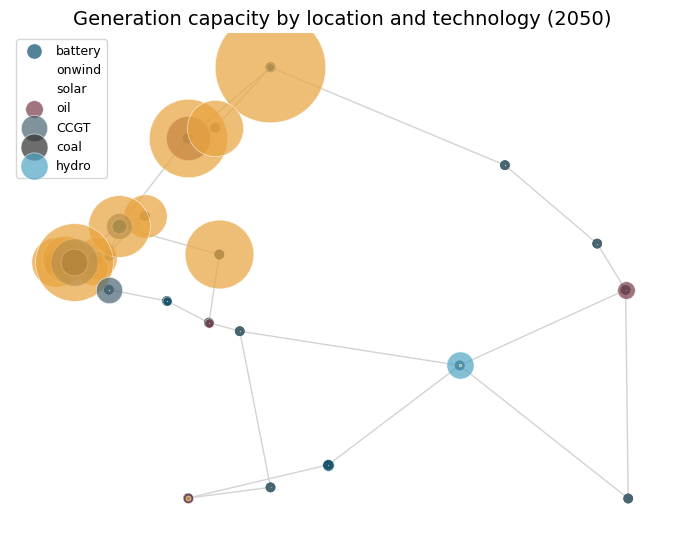

In [138]:

fig, ax = plt.subplots(figsize=(7, 7))
n_b.plot(ax=ax, geomap=False, bus_sizes=0.002, bus_colors=PALETTE["slate"],
         line_widths=1, line_colors="lightgrey")
ax.set_xlim(*geo_bounds(n_b)[0])
ax.set_ylim(*geo_bounds(n_b)[1])

cap_by_bus_carrier = gen_table_b.groupby(["bus", "carrier"])["capacity_mw"].sum()
for (bus, carrier), capval in cap_by_bus_carrier.items():
    if bus in n_b.buses.index and capval > 0:
        x, y = n_b.buses.loc[bus, ["x", "y"]]
        ax.scatter([x], [y], s=capval * 3, color=color_for(carrier), alpha=0.7,
                   edgecolors="white", linewidths=0.5, zorder=5, label=carrier)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=9)
ax.set_title(f"Generation capacity by location and technology ({RUN_YEAR})")
savefig(fig, "generation_data_map")
plt.show()


## 4. Transmission Map

Slide 4. Line widths scaled to capacity, buses labelled with nominal voltage where available.

                        x          y  v_nom
Bus                                        
SN0 0          -15.466400  16.511200  380.0
SN0 1          -16.031600  14.167600  380.0
SN0 10         -16.222700  12.557800  380.0
SN0 11         -16.227300  15.859200  380.0
SN0 12         -14.935700  12.863200  380.0
SN0 13         -12.183247  12.553736  380.0
SN0 14         -15.748100  14.089200  380.0
SN0 15         -16.416300  14.366300  380.0
SN0 16         -16.619900  15.146200  380.0
SN0 17         -17.436600  14.725100  380.0
SN0 18         -17.064500  14.762700  380.0
SN0 19         -15.974500  15.956500  380.0
SN0 2          -16.855500  15.051450  380.0
SN0 20         -12.467900  14.892900  380.0
SN0 21         -17.101500  14.658600  380.0
SN0 22         -16.941900  14.780300  380.0
SN0 23         -17.349000  14.756300  380.0
SN0 3          -13.729700  13.775000  380.0
SN0 4          -17.271900  14.726900  380.0
SN0 5          -15.465700  12.655800  380.0
SN0 6          -13.314700  15.61

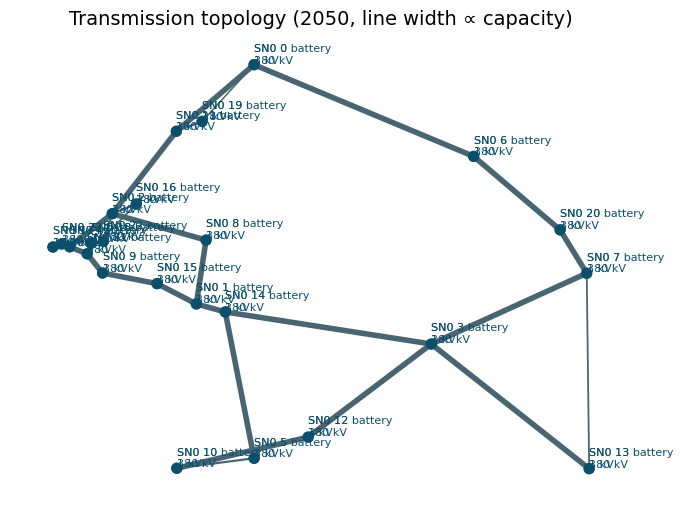

In [139]:

substation_table = n_b.buses[["x", "y", "v_nom"]].copy()
print(substation_table)
substation_table.to_csv(FIG_DIR / "substation_table.csv")

fig, ax = plt.subplots(figsize=(7, 7))
line_cap = n_b.lines.s_nom_opt.where(n_b.lines.s_nom_extendable, n_b.lines.s_nom)
line_widths = 1 + 3 * (line_cap / line_cap.max()) if len(line_cap) and line_cap.max() > 0 else 1.5
n_b.plot(ax=ax, geomap=False, bus_sizes=0.003, bus_colors=PALETTE["blue_teal"],
         line_widths=line_widths, line_colors=PALETTE["slate"])
xlim, ylim = geo_bounds(n_b)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
for bus, row in n_b.buses.iterrows():
    if xlim[0] <= row.x <= xlim[1] and ylim[0] <= row.y <= ylim[1]:
        ax.annotate(f"{bus}\n{row.v_nom:.0f} kV" if row.v_nom else bus, (row.x, row.y),
                    fontsize=8, ha="left", va="bottom", color=PALETTE["blue_teal"])
ax.set_title(f"Transmission topology ({RUN_YEAR}, line width ∝ capacity)")
savefig(fig, "transmission_map")
plt.show()


## 4b. Transmission Topology by Voltage Level (2050)

The Section 4 map above plots the *solved/clustered* network `n_b`. That network doesn't
actually carry real voltage diversity: PyPSA-Earth's `simplify_network_to_base_voltage()`
step maps every line and bus in the reduced representation onto a single voltage layer
(`electricity.base_voltage` in the config -- 380 kV here), so the clustered network can be
solved as one electrical layer. The cell below confirms this directly on `n_b`, then falls
back to the pre-simplification base-network topology -- the OSM-derived substations/lines
before clustering -- which is the only stage where the real voltage mix used to build this
model is still present.

n_b (solved/clustered network): all 31 lines report v_nom = [380.0] kV -- no voltage diversity survives simplification, so the map below instead uses the pre-simplification base-network topology.
saved figures/transmission_map_by_voltage.png


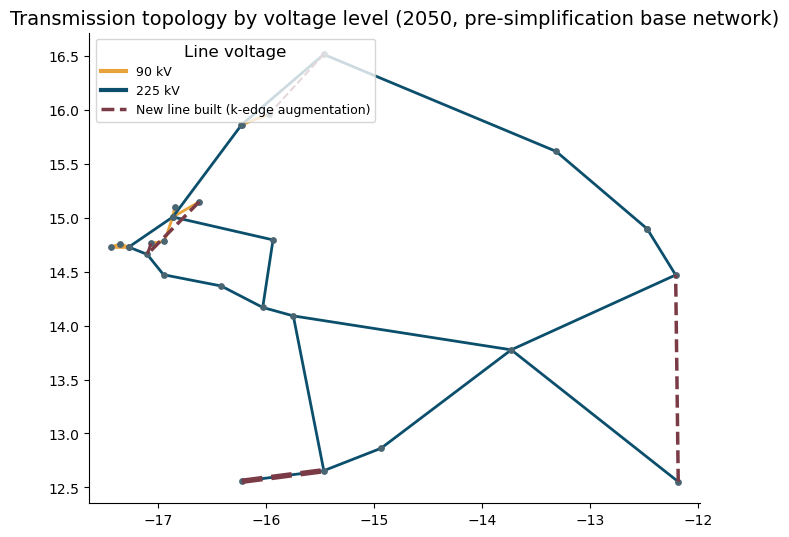


Line count by voltage level:
voltage_kv
90.0     10
225.0    20
Name: count, dtype: int64

5 new lines were built via k-edge connectivity augmentation (bypass the network-wide `ll` transmission limit -- see augmented_line_connections.py):
                                length  s_nom_opt_MVA
Line                                                 
lines new SN0 0 <-> SN0 19 AC    123.2           14.4
lines new SN0 18 <-> SN0 21 AC    18.4           39.7
lines new SN0 16 <-> SN0 21 AC   112.4           50.4
lines new SN0 13 <-> SN0 7 AC    319.3           50.1
lines new SN0 10 <-> SN0 5 AC    124.3           99.3


In [140]:
print(f"n_b (solved/clustered network): all {len(n_b.lines)} lines report v_nom = "
      f"{sorted(n_b.lines.v_nom.unique())} kV -- no voltage diversity survives simplification, "
      f"so the map below instead uses the pre-simplification base-network topology.")

import matplotlib.collections as mcoll

run_b_dir = re.search(r"results/([^/]+)/networks", RUN_B_PATH).group(1)
base_buses = pd.read_csv(f"resources/{run_b_dir}/base_network/all_buses_build_network.csv").set_index("bus_id")
base_lines = pd.read_csv(f"resources/{run_b_dir}/base_network/all_lines_build_network.csv")
base_lines["voltage_kv"] = base_lines["voltage"] / 1000

VOLTAGE_COLORS = {
    90.0: PALETTE["amber"], 132.0: PALETTE["green"], 220.0: PALETTE["slate"],
    225.0: PALETTE["blue_teal"], 300.0: PALETTE["burgundy"], 380.0: "#2F2F2F",
    500.0: "#8B5E3C", 750.0: "#7A9E7E",
}
def voltage_color(v_kv):
    return VOLTAGE_COLORS.get(v_kv, "#999999")

segments, seg_colors = [], []
for _, row in base_lines.iterrows():
    b0, b1 = row.bus0, row.bus1
    if b0 not in base_buses.index or b1 not in base_buses.index:
        continue
    x0, y0 = base_buses.loc[b0, ["lon", "lat"]]
    x1, y1 = base_buses.loc[b1, ["lon", "lat"]]
    segments.append([(x0, y0), (x1, y1)])
    seg_colors.append(voltage_color(row.voltage_kv))

fig, ax = plt.subplots(figsize=(7, 7))
ax.add_collection(mcoll.LineCollection(segments, colors=seg_colors, linewidths=2, zorder=2))
ax.scatter(base_buses.lon, base_buses.lat, s=15, color=PALETTE["slate"], zorder=3)
ax.set_xlim(base_buses.lon.min() - 0.2, base_buses.lon.max() + 0.2)
ax.set_ylim(base_buses.lat.min() - 0.2, base_buses.lat.max() + 0.2)
ax.set_aspect("equal")

# New lines built via k-edge connectivity augmentation (scripts/augmented_line_connections.py).
# These are added AFTER clustering, so they don't exist in the pre-simplification base-network
# CSVs above -- overlaid here using n_b's cluster-node coordinates instead. Unlike every other
# line in this network, these are extendable regardless of the `ll` transmission limit (set
# s_nom_extendable=True directly in augmented_line_connections.py, never reset by
# set_transmission_limit()), so they're the only real transmission investment the solver made.
aug_lines = n_b.lines[n_b.lines.index.str.startswith("lines new")]
aug_max = aug_lines.s_nom_opt.max() if len(aug_lines) else 1.0
for name, row in aug_lines.iterrows():
    x0, y0 = n_b.buses.loc[row.bus0, ["x", "y"]]
    x1, y1 = n_b.buses.loc[row.bus1, ["x", "y"]]
    ax.plot([x0, x1], [y0, y1], color=PALETTE["burgundy"], linestyle="--",
            linewidth=1 + 3 * (row.s_nom_opt / aug_max), zorder=4)

voltage_levels = sorted(base_lines.voltage_kv.unique())
handles = [plt.Line2D([0], [0], color=voltage_color(v), lw=3, label=f"{v:.0f} kV")
           for v in voltage_levels]
if len(aug_lines):
    handles.append(plt.Line2D([0], [0], color=PALETTE["burgundy"], lw=2.5, linestyle="--",
                               label="New line built (k-edge augmentation)"))
ax.legend(handles=handles, loc="upper left", fontsize=9, title="Line voltage")
ax.set_title(f"Transmission topology by voltage level ({RUN_YEAR}, pre-simplification base network)")
savefig(fig, "transmission_map_by_voltage")
plt.show()

print("\nLine count by voltage level:")
print(base_lines.voltage_kv.value_counts().sort_index())

if len(aug_lines):
    print(f"\n{len(aug_lines)} new lines were built via k-edge connectivity augmentation "
          f"(bypass the network-wide `ll` transmission limit -- see augmented_line_connections.py):")
    print(aug_lines[["length", "s_nom_opt"]].round(1).rename(columns={"s_nom_opt": "s_nom_opt_MVA"}))

## 5. Input Data

Slide 5. Assembles the headline input assumptions into one table for the slide.

In [141]:

input_data = pd.DataFrame({
    "parameter": ["VoLL (currency/MWh)", "SOC discount rate", "STP discount rate",
                  "Demand growth (%/yr)", "Carbon price (currency/tCO2)",
                  "Shadow exchange rate premium"],
    "value": [VOLL, SOC_DISCOUNT_RATE, STP_DISCOUNT_RATE, DEMAND_GROWTH_PCT, CARBON_PRICE,
              SHADOW_EXCHANGE_RATE_PREMIUM],
})
fuel_price_rows = pd.DataFrame({
    "parameter": [f"Fuel price, {k} (currency/MWh)" for k in FUEL_PRICE],
    "value": list(FUEL_PRICE.values()),
})
input_data = pd.concat([input_data, fuel_price_rows], ignore_index=True)
print(input_data)
input_data.to_csv(FIG_DIR / "input_data_table.csv", index=False)

if input_data["value"].isna().any():
    print("\nWARNING: some input parameters are still None, fill these in from Ch. 5 before presenting.")


                         parameter        value
0              VoLL (currency/MWh)  1000.000000
1                SOC discount rate     0.060000
2                STP discount rate     0.040000
3             Demand growth (%/yr)     4.000000
4     Carbon price (currency/tCO2)     0.000000
5     Shadow exchange rate premium     0.000000
6  Fuel price, CCGT (currency/MWh)    45.189770
7  Fuel price, coal (currency/MWh)    30.108472
8   Fuel price, oil (currency/MWh)   157.533743


## 6. Typical Demand Profile

saved figures/demand_profile.png


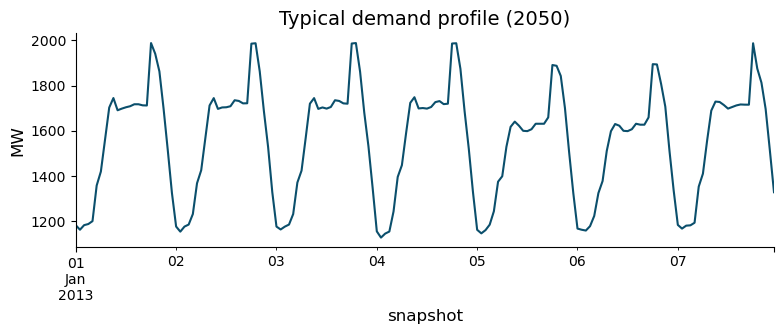

In [142]:

demand = n_b.loads_t.p_set.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 3.5))
if is_multi_period:
    demand.loc[demand.index.get_level_values("period")[0]].plot(ax=ax, color=PALETTE["blue_teal"])
else:
    demand.iloc[: min(len(demand), 24 * 7)].plot(ax=ax, color=PALETTE["blue_teal"])
ax.set_ylabel("MW")
ax.set_title(f"Typical demand profile ({RUN_YEAR})")
savefig(fig, "demand_profile")
plt.show()


## 7. Costs

Slide 7. CAPEX and variable OPEX read directly from the network. **Fixed OPEX (FOM)** is not
a standard PyPSA generator attribute, if it isn't already folded into `capital_cost` in your
model, add it as a separate column here, marked `# TODO` below.

In [143]:

def cost_table(n):
    g = n.generators.copy()
    df = pd.DataFrame({
        "carrier": g.carrier,
        "capex_per_mw": g.capital_cost,
        "var_opex_per_mwh": g.marginal_cost,
        # TODO: add fixed O&M per MW/year here if tracked separately from capital_cost
        # "fom_per_mw_year": ...,
    })
    return df

costs = cost_table(n_b)
print(costs)
costs.to_csv(FIG_DIR / "cost_table.csv")


                                   carrier  capex_per_mw  var_opex_per_mwh
Generator                                                                 
SN0 0 onwind                        onwind  94128.969871      2.492008e-02
SN0 0 solar                          solar  30129.873172      2.079263e-02
SN0 1 oil                              oil  39078.280467      1.575333e+02
SN0 1 onwind                        onwind  94128.969871      2.441241e-02
SN0 1 solar                          solar  30129.873172      2.003368e-02
...                                    ...           ...               ...
SN0 5 battery load shedding  load shedding      0.000000      1.000000e+06
SN0 6 battery load shedding  load shedding      0.000000      1.000000e+06
SN0 7 battery load shedding  load shedding      0.000000      1.000000e+06
SN0 8 battery load shedding  load shedding      0.000000      1.000000e+06
SN0 9 battery load shedding  load shedding      0.000000      1.000000e+06

[105 rows x 3 columns]


## 8. Technical Assumptions

Slide 8. Efficiency and mean capacity factor by technology.

In [144]:

def technical_table(n):
    g = n.generators
    rows = []
    for name, row in g.iterrows():
        if name in n.generators_t.p_max_pu.columns:
            cf = n.generators_t.p_max_pu[name].mean()
        else:
            cf = 1.0
        rows.append({"name": name, "carrier": row.carrier, "efficiency": row.efficiency,
                     "mean_capacity_factor": cf})
    return pd.DataFrame(rows)

tech_table = technical_table(n_b)
print(tech_table)
tech_table.to_csv(FIG_DIR / "technical_assumptions_table.csv", index=False)


                            name        carrier  efficiency  \
0                   SN0 0 onwind         onwind        1.00   
1                    SN0 0 solar          solar        1.00   
2                      SN0 1 oil            oil        0.35   
3                   SN0 1 onwind         onwind        1.00   
4                    SN0 1 solar          solar        1.00   
..                           ...            ...         ...   
100  SN0 5 battery load shedding  load shedding        1.00   
101  SN0 6 battery load shedding  load shedding        1.00   
102  SN0 7 battery load shedding  load shedding        1.00   
103  SN0 8 battery load shedding  load shedding        1.00   
104  SN0 9 battery load shedding  load shedding        1.00   

     mean_capacity_factor  
0                0.269173  
1                0.173796  
2                1.000000  
3                0.124640  
4                0.163843  
..                    ...  
100              1.000000  
101              1.

## 9. Model Validation

Slide 9. Compares modelled generation mix and peak demand against observed values, per
Parzen et al.'s validation approach. **This only works once `OBSERVED_PEAK_DEMAND_MW` and
`OBSERVED_GENERATION_MIX_PCT` in the config cell are filled in from your primary sources.**
This notebook will not fabricate those numbers.

In [145]:

if OBSERVED_PEAK_DEMAND_MW is not None:
    modelled_peak = demand.max()
    print(f"Modelled peak demand: {modelled_peak:.1f} MW")
    print(f"Observed peak demand: {OBSERVED_PEAK_DEMAND_MW:.1f} MW")
    print(f"Difference: {100 * (modelled_peak - OBSERVED_PEAK_DEMAND_MW) / OBSERVED_PEAK_DEMAND_MW:+.1f}%")
else:
    print("Set OBSERVED_PEAK_DEMAND_MW in the config cell to run this check.")

if OBSERVED_GENERATION_MIX_PCT:
    # Uses generation_by_carrier(), not just n_b.generators_t.p, so StorageUnit-based
    # technologies (e.g. hydro) are included in the modelled mix, not silently dropped.
    gen_by_carrier = generation_by_carrier(n_b).sum()
    modelled_mix_pct = 100 * gen_by_carrier / gen_by_carrier.sum()
    compare = pd.DataFrame({
        "modelled_pct": modelled_mix_pct,
        "observed_pct": pd.Series(OBSERVED_GENERATION_MIX_PCT),
    })
    print("\n", compare)

    fig, ax = plt.subplots(figsize=(7, 4))
    compare.plot(kind="bar", ax=ax, color=[PALETTE["blue_teal"], PALETTE["amber"]])
    ax.set_ylabel("% of generation")
    ax.set_title(f"Validation: modelled vs observed generation mix ({RUN_YEAR})")
    savefig(fig, "validation_generation_mix")
    plt.show()
else:
    print("Set OBSERVED_GENERATION_MIX_PCT in the config cell to run this check.")


Set OBSERVED_PEAK_DEMAND_MW in the config cell to run this check.
Set OBSERVED_GENERATION_MIX_PCT in the config cell to run this check.


## 10. Optimal Capacity Built

Slide 10. BESS detection handles both `StorageUnit` and `Store`+`Link` representations,
**check the printed output before trusting anything downstream.** Also reports the capacity
substitution ratio and whether BESS unlocks additional VRE capacity in Run B.

In [146]:

def get_bess_representation(n, carrier=BESS_CARRIER):
    """Detect and summarise the BESS technology in a solved network. Returns None if absent.

    Combines BOTH representations if both are present in the same network -- this model has
    exactly that: a StorageUnit for the named existing/committed BESS projects (Taiba N'Diaye/
    Tobene, Walo, NEA Kolda, Nakhar), and a separate Store+Link pair for the extendable
    candidate fleet the optimizer sizes freely. The original single-representation version of
    this function returned on whichever it found first (StorageUnit), silently undercounting
    total BESS capacity by ~97% (89 MW reported vs. ~2,705 MW actual) since it never checked
    for the Store+Link fleet once a StorageUnit match was found. Fixed here to check both and
    sum them, keeping each component's own breakdown in `components` for anyone who needs the
    split rather than just the total."""
    parts = []

    su_mask = n.storage_units.carrier.eq(carrier) if len(n.storage_units) else pd.Series(dtype=bool)
    if su_mask.any():
        names = n.storage_units.index[su_mask]
        power_mw = n.storage_units.loc[names, "p_nom_opt"].sum()
        energy_mwh = (n.storage_units.loc[names, "p_nom_opt"] * n.storage_units.loc[names, "max_hours"]).sum()
        dispatch = n.storage_units_t.p[names].sum(axis=1)
        soc = n.storage_units_t.state_of_charge[names].sum(axis=1)
        buses = n.storage_units.loc[names, "bus"].unique().tolist()
        parts.append(dict(kind="storage_unit", names=list(names), power_mw=power_mw,
                           energy_mwh=energy_mwh, dispatch=dispatch, soc=soc, buses=buses))

    store_mask = n.stores.carrier.eq(carrier) if len(n.stores) else pd.Series(dtype=bool)
    if store_mask.any():
        store_names = n.stores.index[store_mask]
        energy_mwh = n.stores.loc[store_names, "e_nom_opt"].sum()
        soc = n.stores_t.e[store_names].sum(axis=1)
        store_buses = set(n.stores.loc[store_names, "bus"])

        link_mask = n.links.bus1.isin(store_buses) | n.links.bus0.isin(store_buses)
        link_names = n.links.index[link_mask]
        # Power rating: sum the CHARGER side's p_nom_opt across every BESS bus, not a single
        # network-wide max (the original code's assumption -- fine for one aggregated BESS bus,
        # wrong for this model, which sites BESS at up to 24 nodes). Only the charger carries a
        # nonzero capital_cost here (discharger mirrors it at 0), so charger p_nom_opt is the
        # economically meaningful power figure, consistent with the CAPEX accounting elsewhere.
        charger_names = [l for l in link_names if n.links.loc[l, "bus0"] not in store_buses]
        power_mw = n.links.loc[charger_names, "p_nom_opt"].sum() if charger_names else np.nan

        charge = pd.Series(0.0, index=n.snapshots)
        discharge = pd.Series(0.0, index=n.snapshots)
        for l in link_names:
            flow = n.links_t.p0[l]
            if n.links.loc[l, "bus1"] in store_buses:
                charge += flow.clip(lower=0)
            else:
                discharge += (-flow).clip(lower=0)
        dispatch = discharge - charge
        buses = list(store_buses)
        parts.append(dict(kind="store_link", store_names=list(store_names), link_names=list(link_names),
                           power_mw=power_mw, energy_mwh=energy_mwh, dispatch=dispatch, soc=soc, buses=buses))

    if not parts:
        return None
    if len(parts) == 1:
        return parts[0]

    return dict(
        kind="+".join(p["kind"] for p in parts),
        power_mw=sum(p["power_mw"] for p in parts),
        energy_mwh=sum(p["energy_mwh"] for p in parts),
        dispatch=sum(p["dispatch"] for p in parts),
        soc=sum(p["soc"] for p in parts),
        buses=sorted(set(b for p in parts for b in p["buses"])),
        components=parts,
    )


bess_a = get_bess_representation(n_a)
bess_b = get_bess_representation(n_b)

print("Run A BESS:", "none found (expected)" if bess_a is None else bess_a["kind"])
if bess_b is None:
    print("Run B: no BESS was built or detected, check BESS_CARRIER and rerun.")
else:
    duration_h = bess_b["energy_mwh"] / bess_b["power_mw"] if bess_b["power_mw"] else np.nan
    print(f"Run B BESS ({bess_b['kind']}): {bess_b['power_mw']:.1f} MW, "
          f"{bess_b['energy_mwh']:.1f} MWh, implied duration {duration_h:.2f} h")
    print("Sited at bus(es):", bess_b["buses"])
    if "components" in bess_b:
        print("Breakdown by representation:")
        for p in bess_b["components"]:
            print(f"  {p['kind']:14s} power={p['power_mw']:.1f} MW  energy={p['energy_mwh']:.1f} MWh")


Run A BESS: none found (expected)
Run B BESS (storage_unit+store_link): 2704.7 MW, 16278.8 MWh, implied duration 6.02 h
Sited at bus(es): ['SN0 0', 'SN0 0 battery', 'SN0 1 battery', 'SN0 10 battery', 'SN0 11 battery', 'SN0 12', 'SN0 12 battery', 'SN0 13 battery', 'SN0 14 battery', 'SN0 15', 'SN0 15 battery', 'SN0 16 battery', 'SN0 17 battery', 'SN0 18 battery', 'SN0 19 battery', 'SN0 2', 'SN0 2 battery', 'SN0 20 battery', 'SN0 21 battery', 'SN0 22 battery', 'SN0 23 battery', 'SN0 3 battery', 'SN0 4 battery', 'SN0 5 battery', 'SN0 6 battery', 'SN0 7 battery', 'SN0 8 battery', 'SN0 9 battery']
Breakdown by representation:
  storage_unit   power=89.0 MW  energy=712.0 MWh
  store_link     power=2615.7 MW  energy=15566.8 MWh


         Run A (no BESS)  Run B (BESS included)
carrier                                        
CCGT         1169.425876             711.001321
battery         0.000000              89.000000
coal          155.000131             155.000564
hydro         128.000000             128.000000
oil           861.288572             524.460981
onwind       1265.100702               0.050567
solar        3159.188079            7838.492882
saved figures/capacity_mix_comparison.png


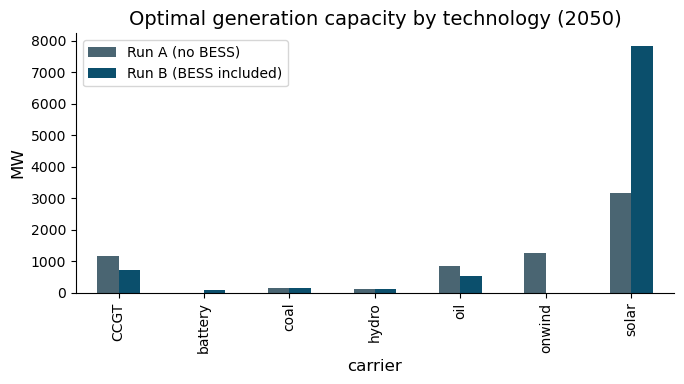


Thermal capacity avoided: 0.0 MW
Capacity substitution ratio: 0.00 MW thermal avoided per MW BESS built
onwind capacity change (Run B minus Run A): -1265.1 MW
solar capacity change (Run B minus Run A): +4679.3 MW


In [147]:

# capacity_by_carrier() is defined in Section 0, combines Generators and StorageUnits so
# hydro (a StorageUnit here) isn't silently missing from this comparison.
cap_a = capacity_by_carrier(n_a)
cap_b = capacity_by_carrier(n_b)
cap_compare = pd.DataFrame({"Run A (no BESS)": cap_a, "Run B (BESS included)": cap_b}).fillna(0)
print(cap_compare)

fig, ax = plt.subplots(figsize=(7, 4))
cap_compare.plot(kind="bar", ax=ax, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("MW")
ax.set_title(f"Optimal generation capacity by technology ({RUN_YEAR})")
savefig(fig, "capacity_mix_comparison")
plt.show()

thermal_avoided_mw = sum(max(cap_a.get(c, 0) - cap_b.get(c, 0), 0) for c in THERMAL_CARRIERS)
if bess_b is not None and bess_b["power_mw"]:
    substitution_ratio = thermal_avoided_mw / bess_b["power_mw"]
    print(f"\nThermal capacity avoided: {thermal_avoided_mw:.1f} MW")
    print(f"Capacity substitution ratio: {substitution_ratio:.2f} MW thermal avoided per MW BESS built")

for c in VRE_CARRIERS:
    if c in cap_a.index or c in cap_b.index:
        delta = cap_b.get(c, 0) - cap_a.get(c, 0)
        print(f"{c} capacity change (Run B minus Run A): {delta:+.1f} MW")


## 10b. BESS Specifications -- Summary & Exploratory Analysis (2050)

Per-site power, energy and implied duration for both BESS representations in this model (see
`get_bess_representation()` above): the four named/committed projects (`StorageUnit`) and the
optimizer-sited candidate fleet (`Store` + charger/discharger `Link` pair, one per clustered
node). Duration for the candidate fleet is **not** fixed by `electricity.max_hours.battery`
-- that cap only constrains the `StorageUnit` representation (all four sit at exactly 8.0 h).
For the `Store`+`Link` fleet, charger power and store energy are sized independently by the
optimizer, so implied duration is an emergent per-site result, not a configured one.

In [148]:
def bess_site_table(n, carrier=BESS_CARRIER):
    """Per-bus BESS power/energy/duration, split by StorageUnit (existing/committed) vs.
    Store+charger-Link (optimizer-sited candidate) representation. Mirrors the component
    coverage of get_bess_representation() above, but broken out per bus instead of summed."""
    su = n.storage_units[n.storage_units.carrier == carrier]
    su_power = su.p_nom_opt.groupby(su.bus).sum()
    su_energy = (su.p_nom_opt * su.max_hours).groupby(su.bus).sum()

    st = n.stores[n.stores.carrier == carrier]
    st_energy = st.e_nom_opt.copy()
    st_energy.index = st.bus.str.replace(f" {carrier}", "", regex=False)
    st_energy = st_energy.groupby(level=0).sum()

    chg = n.links[n.links.carrier == "battery charger"]
    chg_power = chg.p_nom_opt.groupby(chg.bus0).sum()

    buses = n.buses[n.buses.carrier == "AC"].index
    df = pd.DataFrame(index=buses)
    df["existing_power_MW"] = su_power.reindex(buses).fillna(0)
    df["existing_energy_MWh"] = su_energy.reindex(buses).fillna(0)
    df["candidate_power_MW"] = chg_power.reindex(buses).fillna(0)
    df["candidate_energy_MWh"] = st_energy.reindex(buses).fillna(0)
    df["total_power_MW"] = df.existing_power_MW + df.candidate_power_MW
    df["total_energy_MWh"] = df.existing_energy_MWh + df.candidate_energy_MWh
    df["duration_h"] = (df.total_energy_MWh / df.total_power_MW).where(df.total_power_MW > 0)
    return df.sort_values("total_power_MW", ascending=False)

bess_sites_b = bess_site_table(n_b)
active_bess_sites = bess_sites_b[bess_sites_b.total_power_MW > 0.01]
print(f"BESS sited at {len(active_bess_sites)} of {len(bess_sites_b)} clustered nodes ({RUN_YEAR})")
active_bess_sites.round(1)

BESS sited at 24 of 24 clustered nodes (2050)


,existing_power_MW,existing_energy_MWh,candidate_power_MW,candidate_energy_MWh,total_power_MW,total_energy_MWh,duration_h
Bus,,,,,,,
SN0 0,10.0,80.0,815.9,4857.3,825.9,4937.3,6.0
SN0 11,0.0,0.0,391.3,2648.2,391.3,2648.2,6.8
SN0 4,0.0,0.0,337.8,2058.2,337.8,2058.2,6.1
SN0 2,40.0,320.0,239.0,1309.6,279.0,1629.6,5.8
SN0 19,0.0,0.0,231.9,1358.6,231.9,1358.6,5.9
SN0 16,0.0,0.0,122.7,787.7,122.7,787.7,6.4
SN0 8,0.0,0.0,108.1,415.6,108.1,415.6,3.8
SN0 23,0.0,0.0,94.0,495.4,94.0,495.4,5.3
SN0 17,0.0,0.0,66.0,318.5,66.0,318.5,4.8


In [149]:
print("Summary statistics across active BESS sites:")
print(active_bess_sites[["total_power_MW", "total_energy_MWh", "duration_h"]].describe().round(2))

print(f"\nExisting (named/committed) fleet: {bess_sites_b.existing_power_MW.sum():.1f} MW / "
      f"{bess_sites_b.existing_energy_MWh.sum():.1f} MWh across "
      f"{(bess_sites_b.existing_power_MW > 0).sum()} sites")
print(f"Candidate (optimizer-sited) fleet: {bess_sites_b.candidate_power_MW.sum():.1f} MW / "
      f"{bess_sites_b.candidate_energy_MWh.sum():.1f} MWh across "
      f"{(bess_sites_b.candidate_power_MW > 0.01).sum()} sites")
print(f"Combined: {bess_sites_b.total_power_MW.sum():.1f} MW / "
      f"{bess_sites_b.total_energy_MWh.sum():.1f} MWh")

top4_share = active_bess_sites.total_power_MW.nlargest(4).sum() / active_bess_sites.total_power_MW.sum()
print(f"\nTop 4 sites hold {top4_share:.0%} of total installed BESS power.")

Summary statistics across active BESS sites:
       total_power_MW  total_energy_MWh  duration_h
count           24.00             24.00       24.00
mean           112.70            678.28        6.05
std            189.56           1154.63        1.24
min              0.04              0.21        3.48
25%              1.49             10.96        5.36
50%             40.87            264.80        6.04
75%            111.74            568.52        6.91
max            825.87           4937.34        8.00

Existing (named/committed) fleet: 89.0 MW / 712.0 MWh across 4 sites
Candidate (optimizer-sited) fleet: 2615.7 MW / 15566.8 MWh across 24 sites
Combined: 2704.7 MW / 16278.8 MWh

Top 4 sites hold 68% of total installed BESS power.


saved figures/bess_spec_distributions.png


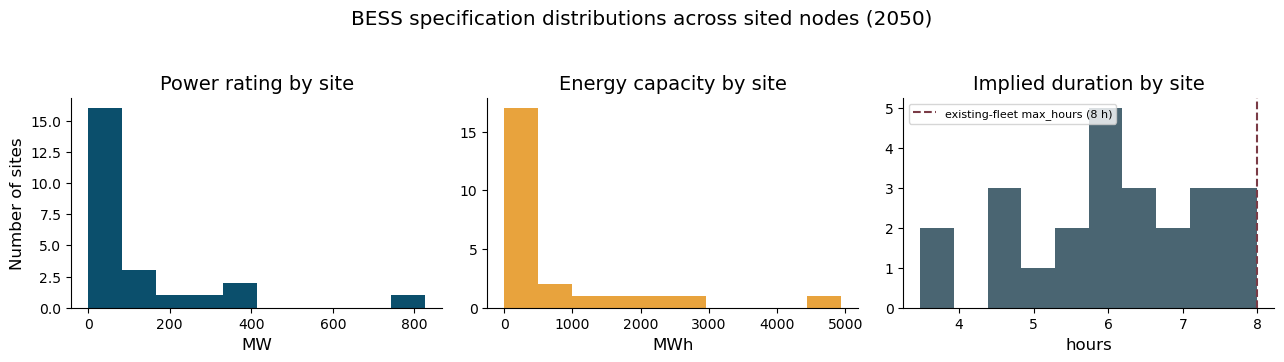

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(active_bess_sites.total_power_MW, bins=10, color=PALETTE["blue_teal"])
axes[0].set_title("Power rating by site")
axes[0].set_xlabel("MW")
axes[0].set_ylabel("Number of sites")

axes[1].hist(active_bess_sites.total_energy_MWh, bins=10, color=PALETTE["amber"])
axes[1].set_title("Energy capacity by site")
axes[1].set_xlabel("MWh")

su_batt = n_b.storage_units[n_b.storage_units.carrier == BESS_CARRIER]
config_duration = su_batt.max_hours.iloc[0] if len(su_batt) else None
axes[2].hist(active_bess_sites.duration_h.dropna(), bins=10, color=PALETTE["slate"])
if config_duration is not None:
    axes[2].axvline(config_duration, color=PALETTE["burgundy"], linestyle="--",
                     label=f"existing-fleet max_hours ({config_duration:.0f} h)")
    axes[2].legend(fontsize=8)
axes[2].set_title("Implied duration by site")
axes[2].set_xlabel("hours")

fig.suptitle(f"BESS specification distributions across sited nodes ({RUN_YEAR})", y=1.03)
savefig(fig, "bess_spec_distributions")
plt.show()

saved figures/bess_siting_concentration.png


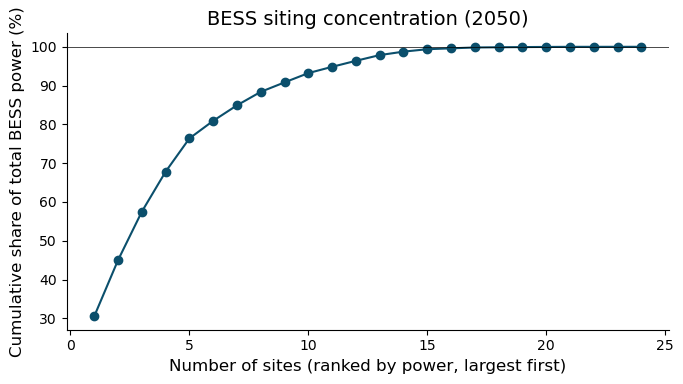

6 of 24 sites account for 80% of total installed BESS power.


In [151]:
cum_share = (active_bess_sites.total_power_MW.sort_values(ascending=False).cumsum()
             / active_bess_sites.total_power_MW.sum())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_share) + 1), cum_share.values * 100, marker="o", color=PALETTE["blue_teal"])
ax.axhline(100, color="black", linewidth=0.5)
ax.set_xlabel("Number of sites (ranked by power, largest first)")
ax.set_ylabel("Cumulative share of total BESS power (%)")
ax.set_title(f"BESS siting concentration ({RUN_YEAR})")
savefig(fig, "bess_siting_concentration")
plt.show()

n_for_80pct = int((cum_share < 0.80).sum() + 1)
print(f"{n_for_80pct} of {len(active_bess_sites)} sites account for 80% of total installed BESS power.")

## 11. System Cost & Decision Metrics

Slide 11. If optimal BESS capacity came out near zero in Section 10, that is itself the
finding under your reference-case parameters, report it as such.

In [152]:

system_cost_a = n_a.objective
system_cost_b = n_b.objective
net_benefit_annual = system_cost_a - system_cost_b

print(f"Run A system cost: {system_cost_a:,.0f}")
print(f"Run B system cost: {system_cost_b:,.0f}")
print(f"Net system benefit (A - B): {net_benefit_annual:,.0f}")


Run A system cost: 528,790,275
Run B system cost: 417,664,872
Net system benefit (A - B): 111,125,403


In [153]:

def npv(rate, cashflows):
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))

def irr(cashflows, bracket=(-0.99, 5)):
    from scipy.optimize import brentq
    f = lambda r: npv(r, cashflows)
    try:
        return brentq(f, *bracket)
    except ValueError:
        return np.nan

if bess_b is not None and bess_b["kind"] == "store_link":
    bess_capex = (
        n_b.stores.loc[bess_b["store_names"], "capital_cost"].mul(
            n_b.stores.loc[bess_b["store_names"], "e_nom_opt"]).sum()
        + n_b.links.loc[bess_b["link_names"], "capital_cost"].mul(
            n_b.links.loc[bess_b["link_names"], "p_nom_opt"]).sum()
    )
elif bess_b is not None and bess_b["kind"] == "storage_unit":
    bess_capex = n_b.storage_units.loc[bess_b["names"], "capital_cost"].mul(
        n_b.storage_units.loc[bess_b["names"], "p_nom_opt"]).sum()
else:
    bess_capex = 0.0

print(f"Implied BESS CAPEX (year 0): {bess_capex:,.0f}")

cashflows = [-bess_capex] + [net_benefit_annual] * APPRAISAL_YEARS
result_npv = npv(DISCOUNT_RATE, cashflows)
result_irr = irr(cashflows)
pv_benefits = npv(DISCOUNT_RATE, [0] + [net_benefit_annual] * APPRAISAL_YEARS)
bcr = pv_benefits / bess_capex if bess_capex else np.nan

print(f"NPV @ {DISCOUNT_RATE:.1%}: {result_npv:,.0f}")
print(f"BCR: {bcr:.2f}")
print(f"EIRR: {result_irr:.1%}" if not np.isnan(result_irr) else "EIRR: does not break even at any feasible rate")


Implied BESS CAPEX (year 0): 0
NPV @ 6.0%: 1,274,599,619
BCR: nan
EIRR: does not break even at any feasible rate


## 12. Value-Stream Decomposition

Slide 12. Traceable back to your Chapter 5 benefit/cost categories, rather than a single
opaque net number. Some lines need model-specific wiring (marked `# TODO`).

Avoided fuel/variable cost by carrier (Run A minus Run B):
carrier
CCGT             1.684112e+08
oil              2.923017e+07
onwind           6.363703e+04
load shedding   -2.240939e+02
coal            -8.937776e+04
solar           -1.372312e+05
dtype: float64

Avoided generation capacity investment by carrier:
carrier
onwind    1.190779e+08
CCGT      4.591534e+07
oil       1.316264e+07
coal     -1.462524e+02
solar    -1.409869e+08
dtype: float64

--- Running decomposition summary (fill in remaining rows) ---
Avoided fuel & variable cost              1.974782e+08
Avoided generation capacity investment    3.716885e+07
BESS CAPEX (annualised, Run B)           -0.000000e+00
Name: value (currency), dtype: float64
saved figures/value_stream_decomposition.png


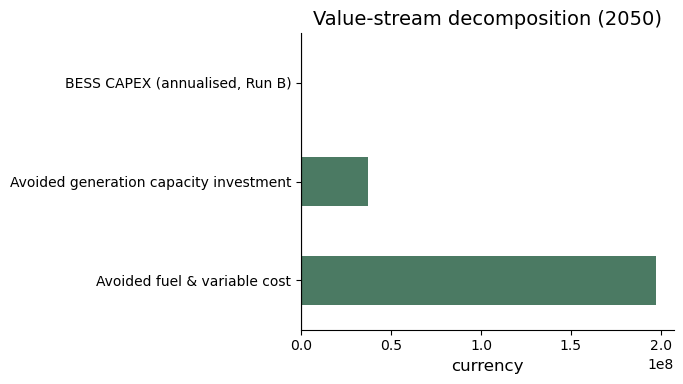

In [154]:

def generation_cost_by_carrier(n):
    g = n.generators
    cost = (n.generators_t.p * g.marginal_cost).sum(axis=0)
    return cost.groupby(g.carrier).sum()

cost_a = generation_cost_by_carrier(n_a)
cost_b = generation_cost_by_carrier(n_b)
all_carriers = cost_a.index.union(cost_b.index)
fuel_cost_avoided = cost_a.reindex(all_carriers, fill_value=0).sub(cost_b.reindex(all_carriers, fill_value=0))
print("Avoided fuel/variable cost by carrier (Run A minus Run B):")
print(fuel_cost_avoided.sort_values(ascending=False))

def capacity_investment(n):
    g = n.generators[n.generators.p_nom_extendable]
    return (g.p_nom_opt * g.capital_cost).groupby(g.carrier).sum()

capex_a = capacity_investment(n_a)
capex_b = capacity_investment(n_b)
all_c = capex_a.index.union(capex_b.index)
avoided_capacity_investment = capex_a.reindex(all_c, fill_value=0).sub(capex_b.reindex(all_c, fill_value=0))
print("\nAvoided generation capacity investment by carrier:")
print(avoided_capacity_investment.sort_values(ascending=False))

# TODO: avoided curtailment value (see Section 13), avoided unserved energy at VoLL (see
# Section 17), emissions value if a carbon price is applied (see Section 16)

summary = pd.Series({
    "Avoided fuel & variable cost": fuel_cost_avoided.sum(),
    "Avoided generation capacity investment": avoided_capacity_investment.sum(),
    "BESS CAPEX (annualised, Run B)": -bess_capex,
}, name="value (currency)")
print("\n--- Running decomposition summary (fill in remaining rows) ---")
print(summary)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [PALETTE["green"] if v >= 0 else PALETTE["burgundy"] for v in summary.values]
summary.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("currency")
ax.set_title(f"Value-stream decomposition ({RUN_YEAR})")
savefig(fig, "value_stream_decomposition")
plt.show()


## 13. Technical Dispatch Behaviour

Slide 13. Dispatch stack on representative days, plus BESS charge/discharge, state of
charge, cycling, and curtailment.

saved figures/dispatch_stack_representative_days.png


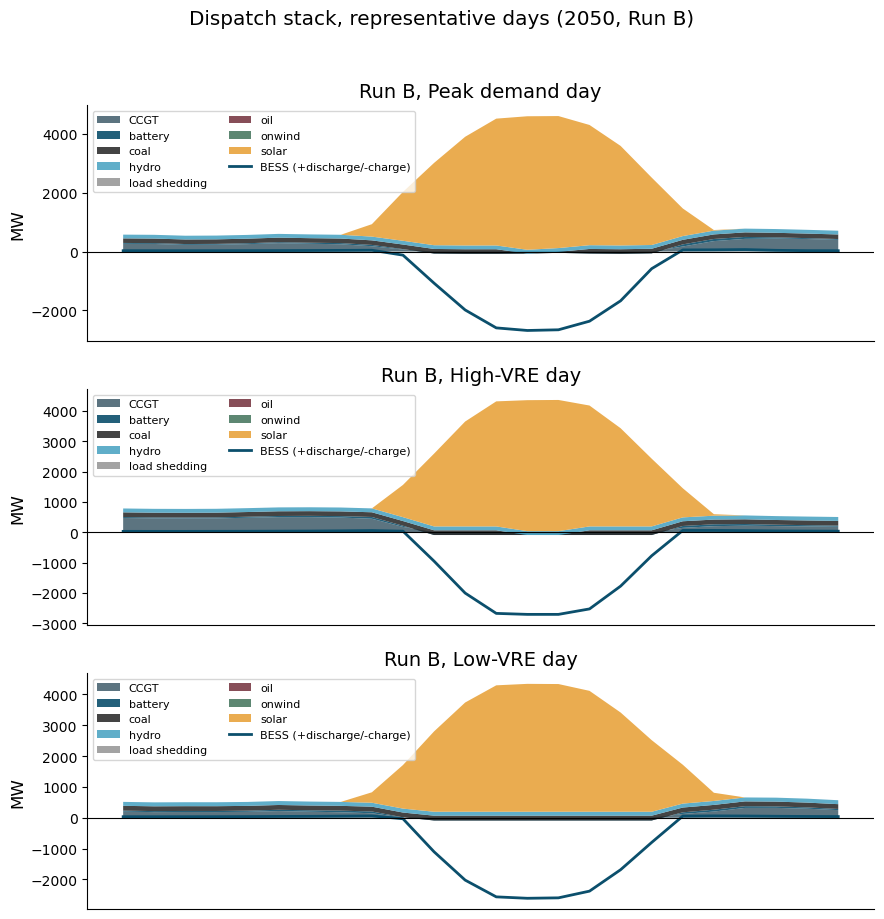

In [155]:

# generation_by_carrier() is defined in Section 0, combines Generators and StorageUnits so
# hydro (a StorageUnit here) appears in the dispatch stack instead of being silently dropped.
gen_a = generation_by_carrier(n_a)
gen_b = generation_by_carrier(n_b)

def plot_dispatch_stack(gen, bess_dispatch, day, title, ax):
    day_gen = gen.loc[day]
    colors = [color_for(c) for c in day_gen.columns]
    ax.stackplot(range(len(day_gen)), day_gen.values.T, labels=day_gen.columns, colors=colors, alpha=0.9)
    if bess_dispatch is not None:
        ax.plot(range(len(day_gen)), bess_dispatch.loc[day].values, color=PALETTE["blue_teal"],
                linewidth=2, label="BESS (+discharge/-charge)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("MW")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.set_xticks([])

demand_b_series = n_b.loads_t.p_set.sum(axis=1)
if is_multi_period:
    ref_period = max(n_b.investment_periods)
    demand_ref = demand_b_series.loc[ref_period]
    gen_b_ref = gen_b.loc[ref_period]
else:
    demand_ref = demand_b_series
    gen_b_ref = gen_b

peak_day = demand_ref.idxmax().normalize() if hasattr(demand_ref.idxmax(), "normalize") else demand_ref.idxmax()
vre_cols = [c for c in n_b.generators.index if n_b.generators.loc[c, "carrier"] in VRE_CARRIERS]
if vre_cols:
    vre_profile = n_b.generators_t.p_max_pu[vre_cols].mean(axis=1)
    vre_profile_ref = vre_profile.loc[ref_period] if is_multi_period else vre_profile
    high_vre_day = vre_profile_ref.idxmax()
    low_vre_day = vre_profile_ref.idxmin()
    if hasattr(high_vre_day, "normalize"):
        high_vre_day, low_vre_day = high_vre_day.normalize(), low_vre_day.normalize()
else:
    high_vre_day = low_vre_day = peak_day

days = {"Peak demand day": peak_day, "High-VRE day": high_vre_day, "Low-VRE day": low_vre_day}

fig, axes = plt.subplots(len(days), 1, figsize=(9, 3 * len(days)))
axes = np.atleast_1d(axes)
bess_dispatch_full = bess_b["dispatch"] if bess_b else None
for ax, (label, day) in zip(axes, days.items()):
    idx = gen_b_ref.index
    day_mask = idx.normalize() == day if hasattr(idx, "normalize") else (idx == day)
    day_slice = idx[day_mask] if hasattr(idx, "normalize") else gen_b_ref.index[gen_b_ref.index == day]
    if is_multi_period:
        full_idx = pd.MultiIndex.from_product([[ref_period], day_slice], names=["period", "timestep"])
    else:
        full_idx = day_slice
    plot_dispatch_stack(gen_b, bess_dispatch_full, full_idx, f"Run B, {label}", ax)
fig.suptitle(f"Dispatch stack, representative days ({RUN_YEAR}, Run B)", y=1.02)
savefig(fig, "dispatch_stack_representative_days")
plt.show()


Full-equivalent cycles over the modelled period: 347.0


saved figures/bess_state_of_charge.png


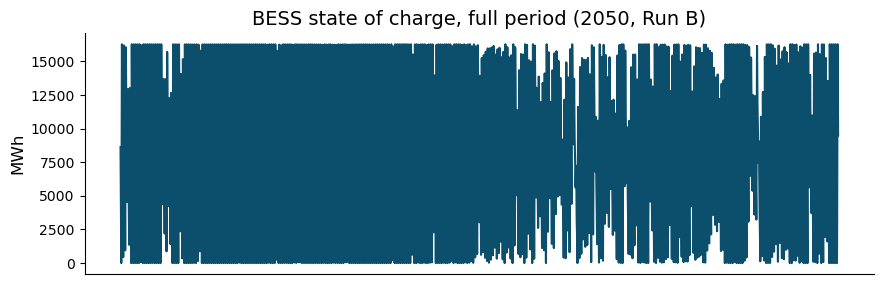

In [156]:

if bess_b is not None:
    charge_mwh = bess_b["dispatch"].clip(upper=0).abs().sum()
    cycles = charge_mwh / bess_b["energy_mwh"] if bess_b["energy_mwh"] else np.nan
    print(f"Full-equivalent cycles over the modelled period: {cycles:.1f}")

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(range(len(bess_b["soc"])), bess_b["soc"].values, color=PALETTE["blue_teal"])
    ax.set_title(f"BESS state of charge, full period ({RUN_YEAR}, Run B)")
    ax.set_ylabel("MWh")
    ax.set_xticks([])
    savefig(fig, "bess_state_of_charge")
    plt.show()


Run A curtailment:
         potential_MWh    actual_MWh  curtailed_MWh  curtailment_pct
onwind   2.980460e+06  2.592776e+06  387684.499699        13.007538
solar    4.733774e+06  4.555597e+06  178176.777270         3.763948

Run B curtailment:
         potential_MWh    actual_MWh  curtailed_MWh  curtailment_pct
onwind   1.069702e+02  9.425948e+01      12.710685        11.882458
solar    1.183631e+07  1.148082e+07  355490.725452         3.003390
saved figures/curtailment_comparison.png


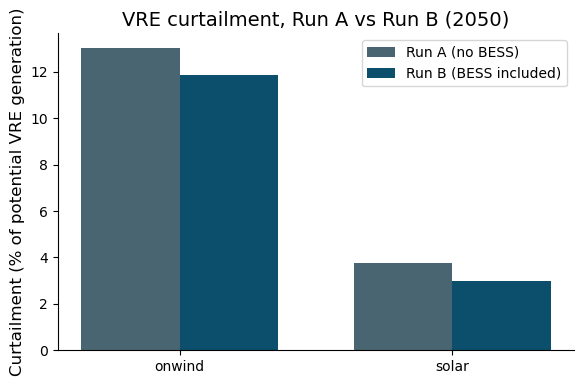

In [157]:

def curtailment_summary(n, carriers=VRE_CARRIERS):
    g = n.generators
    rows = {}
    for c in carriers:
        names = g.index[g.carrier == c]
        if len(names) == 0:
            continue
        cap = g.loc[names, "p_nom_opt"].where(g.loc[names, "p_nom_extendable"], g.loc[names, "p_nom"])
        potential = (n.generators_t.p_max_pu[names] * cap).sum(axis=1)
        actual = n.generators_t.p[names].sum(axis=1)
        curtailed = (potential - actual).clip(lower=0)
        rows[c] = {
            "potential_MWh": potential.sum(), "actual_MWh": actual.sum(),
            "curtailed_MWh": curtailed.sum(),
            "curtailment_pct": 100 * curtailed.sum() / potential.sum() if potential.sum() else np.nan,
        }
    return pd.DataFrame(rows).T

curt_a = curtailment_summary(n_a)
curt_b = curtailment_summary(n_b)
print("Run A curtailment:\n", curt_a)
print("\nRun B curtailment:\n", curt_b)

if len(curt_a) and len(curt_b):
    fig, ax = plt.subplots(figsize=(6, 4))
    idx = curt_a.index
    x = np.arange(len(idx))
    ax.bar(x - 0.18, curt_a["curtailment_pct"], width=0.36, label="Run A (no BESS)", color=PALETTE["slate"])
    ax.bar(x + 0.18, curt_b["curtailment_pct"], width=0.36, label="Run B (BESS included)", color=PALETTE["blue_teal"])
    ax.set_xticks(x); ax.set_xticklabels(idx)
    ax.set_ylabel("Curtailment (% of potential VRE generation)")
    ax.set_title(f"VRE curtailment, Run A vs Run B ({RUN_YEAR})")
    ax.legend()
    savefig(fig, "curtailment_comparison")
    plt.show()


## 14. Energy Mix Over Time

Slide 14. If the model is multi-period, this plots generation share by investment period.
If single-period, it falls back to a within-year monthly aggregation as a proxy, clearly
labelled as such, that is a different claim (seasonal mix, not multi-year evolution) and
should be captioned accordingly on the slide.

saved figures/energy_mix_by_month.png


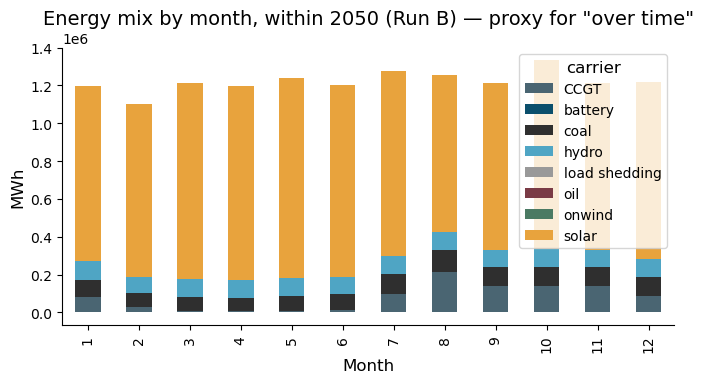

carrier            CCGT    battery           coal         hydro  \
snapshot                                                          
1          82184.878944   1.377271   91421.306190  95213.400958   
2          29291.057434 -19.527776   72700.983768  85987.699868   
3           8725.140290   3.789483   74653.088462  95191.935933   
4           5866.213349  12.559626   70809.764867  92118.072862   
5           7954.770177  -1.137711   78437.196878  95198.522403   
6          10468.790349  -9.321933   84139.148285  92143.519009   
7          94918.814720  52.168675  110163.371254  95230.748463   
8         213671.875421  13.628908  114066.148061  95231.763740   
9         139617.609146 -54.480479   99236.225887  92154.342370   
10        137686.508217  44.486698  101627.310877  95231.945502   
11        138381.000952 -11.451567   99044.530406  92153.418922   
12         87756.464289 -32.091196   98609.453194  95221.960986   

carrier   load shedding       oil     onwind         solar  


In [158]:

if is_multi_period:
    mix_by_period = gen_b.groupby(level="period").sum()
    fig, ax = plt.subplots(figsize=(7, 4))
    mix_by_period.plot(kind="bar", stacked=True, ax=ax,
                        color=[color_for(c) for c in mix_by_period.columns])
    ax.set_ylabel("MWh (sample snapshots)")
    ax.set_title("Energy mix by investment period (Run B)")
    savefig(fig, "energy_mix_by_period")
    plt.show()
    print(mix_by_period)
else:
    monthly_mix = gen_b.groupby(gen_b.index.month).sum()
    fig, ax = plt.subplots(figsize=(7, 4))
    monthly_mix.plot(kind="bar", stacked=True, ax=ax, color=[color_for(c) for c in monthly_mix.columns])
    ax.set_ylabel("MWh")
    ax.set_xlabel("Month")
    ax.set_title(f"Energy mix by month, within {RUN_YEAR} (Run B) — proxy for \"over time\"")
    savefig(fig, "energy_mix_by_month")
    plt.show()
    print(monthly_mix)


## 14b. Energy Mix Across Modelled Years (actual multi-year pathway)

The block above falls back to a within-year monthly proxy because `n.investment_periods` is
empty. **This model's year-by-year view is not a true myopic pathway either** -- each year
(2030, 2035, 2040, 2045, 2050) was solved as its own independent `foresight: overnight` run
(a fresh least-cost build-out for that year's demand and technology costs, with no capacity
carried over from the previous modelled year), not a linked sequence where one year's optimal
capacity becomes the next year's starting point. Read the trend as "what the optimal system
would look like if built fresh for each year," not as a continuous investment trajectory.

Each (BESS state, year) combination is a separate solved network in its own
`results/baseline_{no_bess,bess}_{year}_overnight/` folder (derived automatically below from
`RUN_A_PATH`/`RUN_B_PATH`, so this stays in sync if either path changes), rather than multiple
year-files inside one folder. Uses `generation_by_carrier()` from Section 0 so StorageUnit
(hydro) and Link-based thermal technologies are correctly included, not just plain Generators.


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.

saved figures/energy_mix_across_years.png


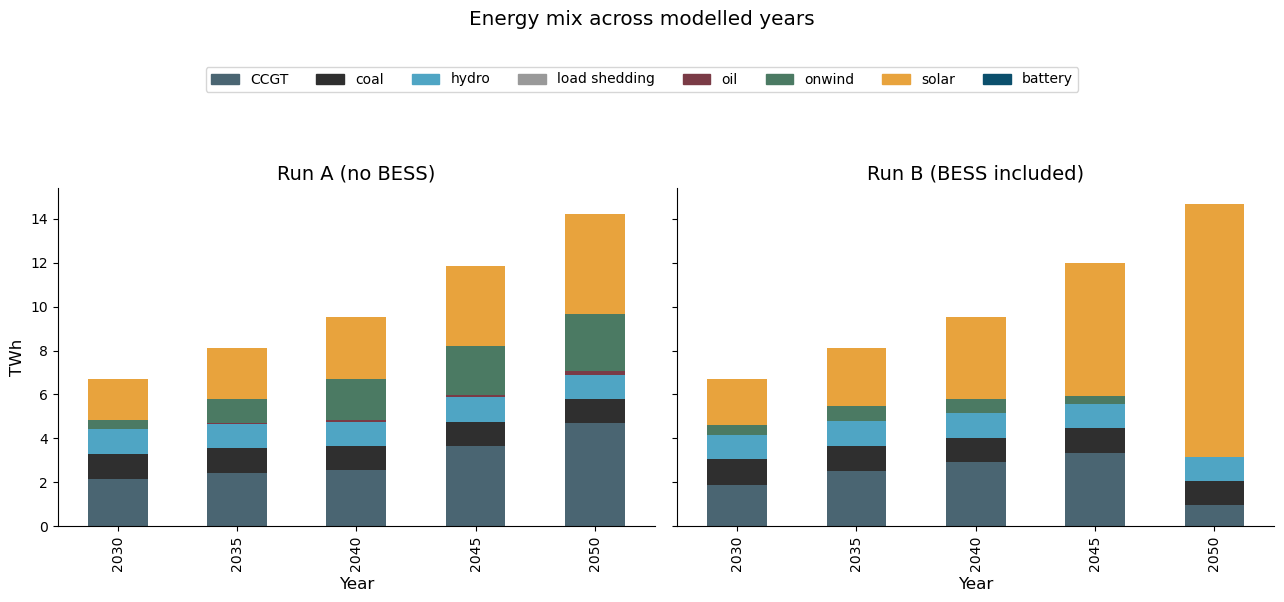

Run A energy mix by year (TWh):
carrier  CCGT  coal  hydro  load shedding   oil  onwind  solar
2030     2.15  1.14   1.12            0.0  0.00    0.44   1.85
2035     2.43  1.12   1.12            0.0  0.02    1.11   2.30
2040     2.57  1.07   1.12            0.0  0.08    1.86   2.80
2045     3.66  1.09   1.12            0.0  0.12    2.23   3.65
2050     4.68  1.09   1.12            0.0  0.19    2.59   4.56

Run B energy mix by year (TWh):
carrier  CCGT  battery  coal  hydro  load shedding  oil  onwind  solar
2030     1.89      0.0  1.15   1.12            0.0  0.0    0.44   2.10
2035     2.52      0.0  1.13   1.12            0.0  0.0    0.71   2.61
2040     2.92     -0.0  1.11   1.12            0.0  0.0    0.66   3.72
2045     3.35     -0.0  1.10   1.12            0.0  0.0    0.34   6.08
2050     0.96     -0.0  1.09   1.12            0.0  0.0    0.00  11.48


In [159]:

# --- Energy mix across all modelled years (one independent overnight solve per year) ---
import re

YEARS = [2030, 2035, 2040, 2045, 2050]

def _run_path_for_year(example_path, year):
    """Given RUN_A_PATH or RUN_B_PATH (results/baseline_{bess_tag}_{year}_overnight/networks/...),
    swap in a different year, keeping the BESS tag and filename the same."""
    p = Path(example_path)
    idx = p.parts.index("results")
    run_dir = p.parts[idx + 1]
    new_run_dir = re.sub(r"_(20[2-9]\d)_", f"_{year}_", run_dir, count=1)
    return Path(*p.parts[: idx + 1]) / new_run_dir / Path(*p.parts[idx + 2 :])

def load_energy_mix_by_year(example_path, years=YEARS):
    mix = {}
    for year in years:
        path = _run_path_for_year(example_path, year)
        if not path.exists():
            print(f"missing: {path}")
            continue
        n_year = pypsa.Network(str(path))
        mix[year] = generation_by_carrier(n_year).sum()
    return pd.DataFrame(mix).T.fillna(0)  # index=year, columns=carrier

mix_a_by_year = load_energy_mix_by_year(RUN_A_PATH)
mix_b_by_year = load_energy_mix_by_year(RUN_B_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, mix, title in [(axes[0], mix_a_by_year, "Run A (no BESS)"),
                        (axes[1], mix_b_by_year, "Run B (BESS included)")]:
    mix_twh = mix / 1e6  # MWh -> TWh
    mix_twh.plot(kind="bar", stacked=True, ax=ax, color=[color_for(c) for c in mix_twh.columns], legend=False)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("TWh")

all_labels = list(dict.fromkeys(list(mix_a_by_year.columns) + list(mix_b_by_year.columns)))
handles = [plt.Rectangle((0, 0), 1, 1, color=color_for(c)) for c in all_labels]
fig.legend(handles, all_labels, loc="upper center", ncol=len(all_labels), bbox_to_anchor=(0.5, 1.1))
fig.suptitle("Energy mix across modelled years", y=1.2)
savefig(fig, "energy_mix_across_years")
plt.show()

print("Run A energy mix by year (TWh):")
print((mix_a_by_year / 1e6).round(2))
print("\nRun B energy mix by year (TWh):")
print((mix_b_by_year / 1e6).round(2))


## 15. Network & Congestion Results

Slide 15.

In [160]:
if len(n_b.lines):
    def line_loading(n):
        """Line utilization relative to its actual operational limit, s_nom_opt * s_max_pu
        (the N-1 security margin applied during solving), not s_nom_opt alone. With
        lines.s_max_pu = 0.7 in this model, dividing by s_nom_opt alone caps this metric at
        0.70, so the ">=99%" congestion check below always reported zero everywhere regardless
        of actual congestion. Confirmed against the solved networks: corrected loading reaches
        ~1.00 (binding) on several lines in both runs that the uncorrected version silently
        missed entirely.
        """
        s_nom = n.lines.s_nom_opt.where(n.lines.s_nom_extendable, n.lines.s_nom)
        return n.lines_t.p0.abs().div(s_nom * n.lines.s_max_pu, axis=1)

    loading_a = line_loading(n_a)
    loading_b = line_loading(n_b)

    congested_hours_a = (loading_a >= 0.99).sum()
    congested_hours_b = (loading_b >= 0.99).sum()
    print("Congestion hours (>=99% of operational limit) per line, Run A (nonzero only):")
    print(congested_hours_a[congested_hours_a > 0].sort_values(ascending=False))
    print("\nCongestion hours (>=99% of operational limit) per line, Run B (nonzero only):")
    print(congested_hours_b[congested_hours_b > 0].sort_values(ascending=False))

    price_compare = pd.DataFrame({"Run A": n_a.buses_t.marginal_price.mean(),
                                   "Run B": n_b.buses_t.marginal_price.mean()})
    print("\nMean nodal price by bus:\n", price_compare)
else:
    print("No Lines in this network, skipping.")

Congestion hours (>=99% of operational limit) per line, Run A (nonzero only):
Line
lines new SN0 16 <-> SN0 21 AC    645
12                                632
13                                521
6                                 441
7                                 413
22                                369
lines new SN0 0 <-> SN0 19 AC     351
19                                163
lines new SN0 18 <-> SN0 21 AC    111
lines new SN0 10 <-> SN0 5 AC     105
2                                  60
lines new SN0 13 <-> SN0 7 AC      16
dtype: int64

Congestion hours (>=99% of operational limit) per line, Run B (nonzero only):
Line
lines new SN0 10 <-> SN0 5 AC     1859
lines new SN0 13 <-> SN0 7 AC      849
6                                  756
22                                 576
lines new SN0 0 <-> SN0 19 AC      572
lines new SN0 18 <-> SN0 21 AC     497
lines new SN0 16 <-> SN0 21 AC     430
7                                  359
23                                 340
2            

## 15b. Transmission Congestion Map (2050)

Mean line loading (Section 15's corrected `line_loading()`, relative to the actual
`s_nom_opt * s_max_pu` operational limit) plotted spatially for both runs side by side, so
congestion hotspots -- and whether BESS visibly relieves or shifts them -- are visible
directly rather than buried in a per-line table. Line width still scales with built
capacity, as in the other network maps; color now encodes utilization instead.

/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_20803/3732167689.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(path, dpi=300, bbox_inches="tight")


saved figures/congestion_map_mean_loading.png


/Users/william/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


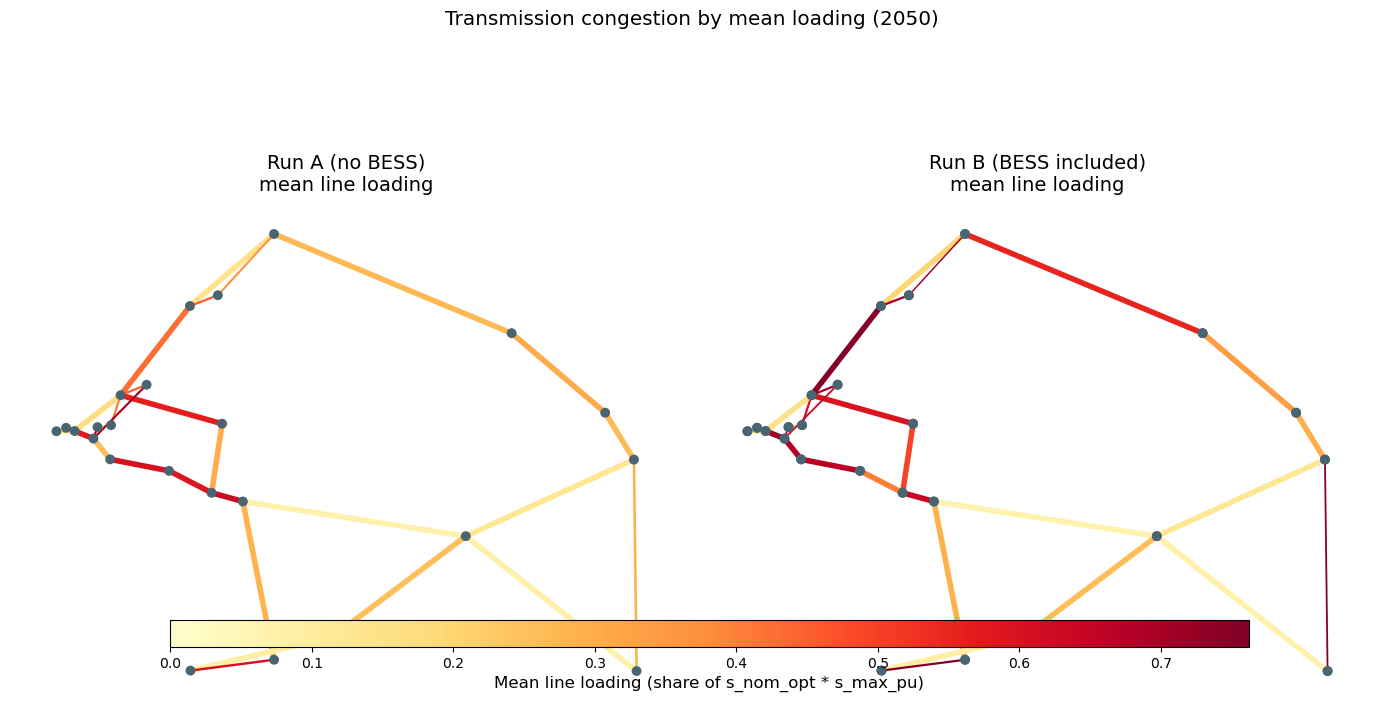

Lines with >=99%-loaded hours in either run:
                                Run A congested hours  Run B congested hours
Line                                                                        
lines new SN0 16 <-> SN0 21 AC                    645                    430
12                                                632                     25
13                                                521                    170
6                                                 441                    756
7                                                 413                    359
22                                                369                    576
lines new SN0 0 <-> SN0 19 AC                     351                    572
19                                                163                      3
lines new SN0 18 <-> SN0 21 AC                    111                    497
lines new SN0 10 <-> SN0 5 AC                     105                   1859
2                              

In [161]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
mean_loading_a = loading_a.mean()
mean_loading_b = loading_b.mean()
vmax = max(mean_loading_a.max(), mean_loading_b.max())
cmap = plt.cm.YlOrRd

for ax, n, mean_loading, label in [
    (axes[0], n_a, mean_loading_a, "Run A (no BESS)"),
    (axes[1], n_b, mean_loading_b, "Run B (BESS included)"),
]:
    s_nom = n.lines.s_nom_opt.where(n.lines.s_nom_extendable, n.lines.s_nom)
    line_widths = 1 + 3 * (s_nom / s_nom.max()) if s_nom.max() > 0 else 1.5
    # pypsa's n.plot() line_colors wants per-line color specs (e.g. hex strings), not raw
    # RGBA arrays from a colormap -- converting explicitly avoids a DataFrame-construction
    # error from passing a 2D RGBA array straight through.
    line_colors = [mcolors.to_hex(cmap(v)) for v in (mean_loading.reindex(n.lines.index) / vmax)]
    n.plot(ax=ax, geomap=False, bus_sizes=0.002, bus_colors=PALETTE["slate"],
           line_widths=line_widths, line_colors=line_colors)
    xlim, ylim = geo_bounds(n)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"{label}\nmean line loading")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05, aspect=40)
cbar.set_label("Mean line loading (share of s_nom_opt * s_max_pu)")
fig.suptitle(f"Transmission congestion by mean loading ({RUN_YEAR})", y=1.02)
savefig(fig, "congestion_map_mean_loading")
plt.show()

worst = pd.DataFrame({
    "Run A congested hours": congested_hours_a,
    "Run B congested hours": congested_hours_b,
}).loc[lambda d: (d["Run A congested hours"] > 0) | (d["Run B congested hours"] > 0)]
print("Lines with >=99%-loaded hours in either run:")
print(worst.sort_values("Run A congested hours", ascending=False))

## 15c. Shadow Price of Electricity, Representative Week (2050)

Nodal shadow price (`n.buses_t.marginal_price`, the dual of each bus's power-balance
constraint) for both runs, one representative week centred on the system peak-demand day.
Shown as mean-across-buses plus the min-max band across all buses at each hour, so both the
price level and the spatial (nodal) price dispersion -- a direct signature of transmission
congestion -- are visible together.

Note the y-axis is `symlog`, not linear: Run A briefly spikes to ~54,000 currency/MWh at bus
SN0 19 (checked directly -- 2013-10-12 20:00, not in this particular week but the same pattern
recurs at 2013-10-27 19:00, which *is* in this window at ~43,700). At that hour, local wind is
almost becalmed (`p_max_pu` ~0.02), solar is zero (evening), and the only line serving that bus
is loaded at exactly 100%: bus SN0 19 is import-constrained with essentially no local supply,
so the shadow price rises toward (but doesn't fully reach) the load-shedding penalty even
though dispatched shedding stays numerically ~0. This is a **congestion-driven near-scarcity
price spike, not actual unserved energy** -- Section 17 already confirmed 0 real shedding
hours all year. Run B shows nothing resembling this anywhere in the full year (max nodal price
177.67 currency/MWh, in line with the most expensive real generator) -- i.e. BESS is
eliminating these congestion price spikes entirely at this node, a reliability/price-
stability value stream that a pure unserved-energy count misses completely.

saved figures/shadow_price_representative_week.png


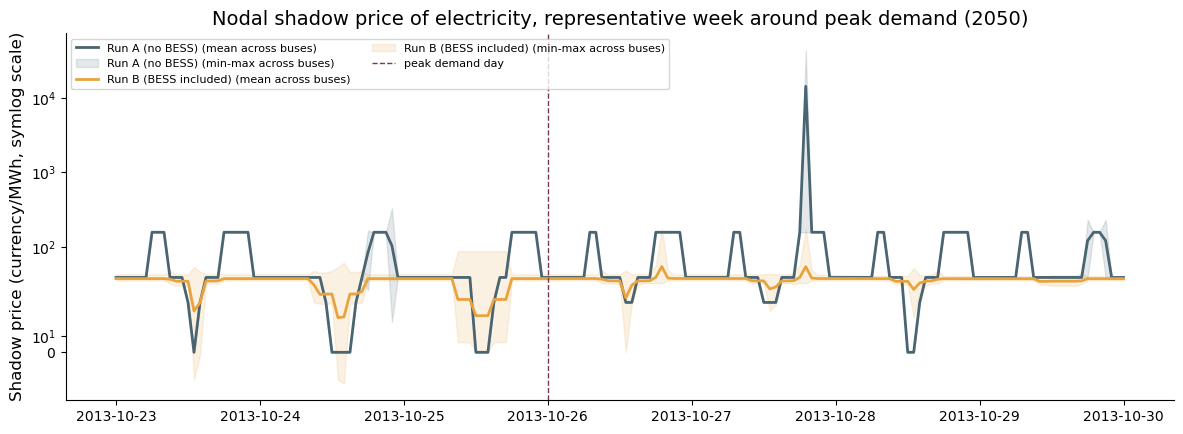

Bus-hours over 1,000 currency/MWh, full year -- Run A: 43 of 210240, Run B: 0 of 420480
Max nodal price, full year -- Run A: 54,434.2, Run B: 177.7


In [168]:
demand_b_series = n_b.loads_t.p_set.sum(axis=1)
peak_day = demand_b_series.idxmax().normalize()
week_start = peak_day - pd.Timedelta(days=3)
week_end = week_start + pd.Timedelta(days=7)

price_a_week = n_a.buses_t.marginal_price.loc[week_start:week_end]
price_b_week = n_b.buses_t.marginal_price.loc[week_start:week_end]

fig, ax = plt.subplots(figsize=(12, 4.5))
for label, price_week, color in [("Run A (no BESS)", price_a_week, PALETTE["slate"]),
                                   ("Run B (BESS included)", price_b_week, PALETTE["amber"])]:
    mean_price = price_week.mean(axis=1)
    min_price = price_week.min(axis=1)
    max_price = price_week.max(axis=1)
    ax.plot(mean_price.index, mean_price.values, color=color, linewidth=2,
            label=f"{label} (mean across buses)")
    ax.fill_between(mean_price.index, min_price.values, max_price.values, color=color, alpha=0.15,
                     label=f"{label} (min-max across buses)")

# symlog handles the multi-order-of-magnitude congestion spike in Run A (tens of thousands of
# currency/MWh) and the small negative prices that show up in Run B (VRE surplus /
# curtailment-adjacent hours) on one axis, without a linear scale squashing the normal
# 0-160 currency/MWh range down to an invisible sliver near zero.
ax.set_yscale("symlog", linthresh=50)
ax.axvline(peak_day, color=PALETTE["burgundy"], linestyle="--", linewidth=1, label="peak demand day")
ax.set_ylabel("Shadow price (currency/MWh, symlog scale)")
ax.set_title(f"Nodal shadow price of electricity, representative week around peak demand ({RUN_YEAR})")
ax.legend(fontsize=8, ncol=2, loc="upper left")
savefig(fig, "shadow_price_representative_week")
plt.show()

flat_a = n_a.buses_t.marginal_price.stack()
flat_b = n_b.buses_t.marginal_price.stack()
print(f"Bus-hours over 1,000 currency/MWh, full year -- Run A: {(flat_a > 1000).sum()} of {len(flat_a)}, "
      f"Run B: {(flat_b > 1000).sum()} of {len(flat_b)}")
print(f"Max nodal price, full year -- Run A: {flat_a.max():,.1f}, Run B: {flat_b.max():,.1f}")

## 16. Emissions

Slide 16.

In [163]:

def co2_atmosphere_emissions(n):
    '''Total tCO2 emitted to atmosphere over the modelled period, read directly from the
    "co2 atmosphere" Store's state of charge, the model's own CO2 balance from solving,
    rather than recomputed from an assumed emission-factor table.'''
    e = n.stores_t.e["co2 atmosphere"]
    return e.iloc[-1] - e.iloc[0]

def co2_emissions_by_link_carrier(n):
    '''Breaks the atmosphere total down by the Link carrier that emitted it (e.g. CCGT, oil,
    coal, SMR), by summing flow into whichever bus position ("bus1"/"bus2"/"bus3") equals
    "co2 atmosphere" for each link, weighted by that position's efficiency. CO2 routed to
    "co2 stored" instead (e.g. captured by SMR CC) is correctly excluded, it never reaches
    the atmosphere bus. Keyed by the conversion technology (CCGT, SMR, ...), not by raw fuel,
    since the same fuel (gas) can be converted via multiple technologies with different
    emission factors.'''
    total = pd.Series(dtype=float)
    for bus_col, eff_col in [("bus1", "efficiency"), ("bus2", "efficiency2"), ("bus3", "efficiency3")]:
        if bus_col not in n.links.columns or eff_col not in n.links.columns:
            continue
        mask = n.links[bus_col] == "co2 atmosphere"
        if not mask.any():
            continue
        names = n.links.index[mask]
        flow = n.links_t.p0[names].mul(n.links.loc[names, eff_col], axis=1).sum(axis=0)
        total = total.add(flow.groupby(n.links.loc[names, "carrier"]).sum(), fill_value=0)
    return total.sort_values(ascending=False)

if "co2 atmosphere" in n_a.stores.index and "co2 atmosphere" in n_b.stores.index:
    total_a = co2_atmosphere_emissions(n_a)
    total_b = co2_atmosphere_emissions(n_b)
    em_a = co2_emissions_by_link_carrier(n_a)
    em_b = co2_emissions_by_link_carrier(n_b)

    print(f"Total emissions, Run A: {total_a:,.0f} tCO2 (link breakdown reconciles to {em_a.sum():,.0f})")
    print(f"Total emissions, Run B: {total_b:,.0f} tCO2 (link breakdown reconciles to {em_b.sum():,.0f})")
    print(f"\nTotal emissions avoided: {total_a - total_b:,.0f} tCO2")

    print("\nEmissions by carrier, Run A (tCO2):\n", em_a)
    print("\nEmissions by carrier, Run B (tCO2):\n", em_b)

    total_gen_a = generation_by_carrier(n_a).sum().sum()
    total_gen_b = generation_by_carrier(n_b).sum().sum()
    print(f"\nEmissions intensity, Run A: {total_a / total_gen_a:.3f} tCO2/MWh")
    print(f"Emissions intensity, Run B: {total_b / total_gen_b:.3f} tCO2/MWh")

    if CARBON_PRICE:
        print(f"Emissions value avoided at {CARBON_PRICE}/tCO2: {(total_a - total_b) * CARBON_PRICE:,.0f}")
else:
    print("No 'co2 atmosphere' store found in one or both networks, this model doesn't track CO2 "
          "this way, fall back to carrier-level co2_emissions (n.carriers) x dispatch instead.")


No 'co2 atmosphere' store found in one or both networks, this model doesn't track CO2 this way, fall back to carrier-level co2_emissions (n.carriers) x dispatch instead.


## 17. Reliability

Slide 17. Only meaningful if your model represents scarcity, e.g. via a high-marginal-cost
load-shedding generator, adjust `SLACK_CARRIER` to match your setup.

In [164]:
SLACK_CARRIER = "load shedding"  # TODO: set to match your model, or None if scarcity isn't modelled

def unserved_energy(n, slack_carrier=SLACK_CARRIER):
    if slack_carrier is None or slack_carrier not in n.generators.carrier.values:
        return None
    names = n.generators.index[n.generators.carrier == slack_carrier]
    return n.generators_t.p[names].sum(axis=1)

ue_a = unserved_energy(n_a)
ue_b = unserved_energy(n_b)
if ue_a is not None:
    print(f"Run A unserved energy: {ue_a.sum():,.1f} MWh, valued at VoLL: {ue_a.sum() * VOLL:,.0f}")
    print(f"Run B unserved energy: {ue_b.sum():,.1f} MWh, valued at VoLL: {ue_b.sum() * VOLL:,.0f}")
    print(f"Avoided unserved energy value: {(ue_a.sum() - ue_b.sum()) * VOLL:,.0f}")
else:
    print("No slack/load-shedding carrier found, scarcity is not represented in this model.")


Run A unserved energy: 0.0 MWh, valued at VoLL: 0
Run B unserved energy: 0.0 MWh, valued at VoLL: 0
Avoided unserved energy value: -0


## 18. Map: Generation + Storage + Transmission in Final Year

Slide 18. Uses the final investment period if multi-period, otherwise the single solved
state (which already represents "the future" relative to today, for a single-horizon
expansion run).

saved figures/system_map_final_year.png


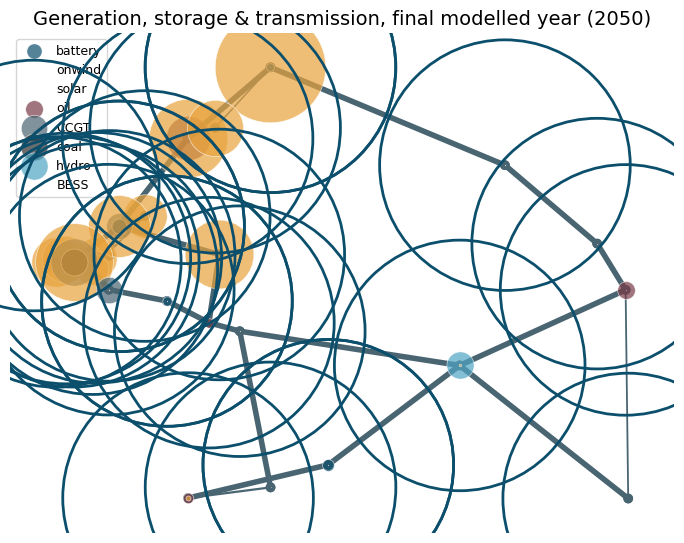

In [165]:

if is_multi_period:
    final_period = max(n_b.investment_periods)
    active_gens = n_b.generators[n_b.generators.build_year <= final_period]
    active_su = n_b.storage_units[n_b.storage_units.build_year <= final_period]
    active_links = n_b.links[n_b.links.build_year <= final_period]
    map_year_label = final_period
else:
    active_gens = n_b.generators
    active_su = n_b.storage_units
    active_links = n_b.links
    map_year_label = RUN_YEAR
active_gens = active_gens[~active_gens.carrier.isin(NON_PHYSICAL_CARRIERS)]
active_gens = active_gens[n_b.buses["carrier"].reindex(active_gens["bus"]).values == "AC"]

cap_final = active_gens.p_nom_opt.where(active_gens.p_nom_extendable, active_gens.p_nom)
cap_by_bus_carrier = cap_final.groupby([active_gens.bus, active_gens.carrier]).sum()

# Include StorageUnit-based capacity (e.g. hydro), otherwise silently absent just because
# it isn't a Generator.
if len(active_su):
    su_cap_final = active_su.p_nom_opt.where(active_su.p_nom_extendable, active_su.p_nom)
    su_cap_by_bus_carrier = su_cap_final.groupby([active_su.bus, active_su.carrier]).sum()
    cap_by_bus_carrier = cap_by_bus_carrier.add(su_cap_by_bus_carrier, fill_value=0)

# Include the AC-output conversion Links (e.g. CCGT/oil/coal power plants): their real
# electrical capacity lives here, not on the fuel-supply Generator (see Section 0).
# NOTE: the grouper is renamed "bus1" -> "bus", otherwise .add() below treats the two
# differently-named MultiIndex levels as distinct and creates a 3-level index instead of
# aligning by (bus, carrier).
is_ac_output = n_b.buses["carrier"].reindex(active_links["bus1"]).values == "AC"
is_bess_link = active_links["carrier"].isin(["battery charger", "battery discharger"])
active_elink = active_links[is_ac_output & ~is_bess_link]
if len(active_elink):
    el_cap_final = active_elink.p_nom_opt.where(active_elink.p_nom_extendable, active_elink.p_nom)
    el_cap_by_bus_carrier = el_cap_final.groupby([active_elink.bus1.rename("bus"), active_elink.carrier]).sum()
    cap_by_bus_carrier = cap_by_bus_carrier.add(el_cap_by_bus_carrier, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 7))
line_cap = n_b.lines.s_nom_opt.where(n_b.lines.s_nom_extendable, n_b.lines.s_nom)
line_widths = 1 + 3 * (line_cap / line_cap.max()) if len(line_cap) and line_cap.max() > 0 else 1.5
n_b.plot(ax=ax, geomap=False, bus_sizes=0.002, bus_colors=PALETTE["slate"],
         line_widths=line_widths, line_colors=PALETTE["slate"])
ax.set_xlim(*geo_bounds(n_b)[0])
ax.set_ylim(*geo_bounds(n_b)[1])

for (bus, carrier), capval in cap_by_bus_carrier.items():
    if bus in n_b.buses.index and capval > 0:
        x, y = n_b.buses.loc[bus, ["x", "y"]]
        ax.scatter([x], [y], s=capval * 3, color=color_for(carrier), alpha=0.7,
                   edgecolors="white", linewidths=0.5, zorder=5, label=carrier)

if bess_b is not None:
    for bus in bess_b["buses"]:
        if bus in n_b.buses.index:
            x, y = n_b.buses.loc[bus, ["x", "y"]]
            ax.scatter([x], [y], s=bess_b["energy_mwh"] * 2, facecolors="none",
                       edgecolors=PALETTE["blue_teal"], linewidths=2, zorder=6, label="BESS")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=9)
ax.set_title(f"Generation, storage & transmission, final modelled year ({map_year_label})")
savefig(fig, "system_map_final_year")
plt.show()


## 19. Assumptions & Limitations

Slide 19.

- **Single weather year:** if either run uses one weather year, inter-annual VRE variability
  is not captured, flag this as a limitation on curtailment, siting, and reliability results.
- **Myopic vs perfect foresight:** stated explicitly in Section 2, restate here for the slide.
- **Sensitivity / Monte Carlo:** deferred for now, note this as a scope decision, EMA Workbench
  flagged as a discussion-chapter framing for robustness to deep uncertainty if reviewers press
  on it.
- **Existing BESS (Tobène & Walo):** confirmed excluded-only in Run A. A fixed-in-both
  variant, testing only *additional* BESS beyond what's committed, would be a separate pair
  of runs.
